In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "src" / "drift_lab").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", PROJECT_ROOT)

Project root: D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting


In [2]:
import time
import pandas as pd
import numpy as np

from drift_lab.aemo import loader
from drift_lab.forecasting.seasonal_naive import SeasonalNaive

In [3]:
REGION = "NSW1"
TARGET_COLUMN = "TOTALDEMAND"

train, calibration, test = loader.load(REGION)

def demand_series(frame):
    return pd.Series(
        frame[TARGET_COLUMN].to_numpy(),
        index=pd.DatetimeIndex(frame["SETTLEMENTDATE"]),
        name=TARGET_COLUMN,
    )

train_y = demand_series(train)
cal_y = demand_series(calibration)
test_y = demand_series(test)

print("Train:", train_y.index.min(), "to", train_y.index.max(), len(train_y))
print("Calibration:", cal_y.index.min(), "to", cal_y.index.max(), len(cal_y))
print("Test:", test_y.index.min(), "to", test_y.index.max(), len(test_y))

=== AEMO Data Quality Check ===
Rows before cleaning: 302448
Regions: ['NSW1']

Invalid timestamps: 0
Out-of-order timestamps: 429
Date range: 2018-01-01 00:30:00 to 2024-01-01 00:00:00

Exact duplicate rows: 0
Conflicting duplicate timestamp rows: 0

Missing values:
REGION            0
SETTLEMENTDATE    0
TOTALDEMAND       0
RRP               0
PERIODTYPE        0
dtype: int64

30-minute period:
Expected interval: 0 days 00:30:00
Unexpected intervals: 0

5-minute period:
Expected interval: 0 days 00:05:00
Unexpected intervals: 0

PERIODTYPE values:
PERIODTYPE
TRADE    302448
Name: count, dtype: int64

Negative TOTALDEMAND values: 0
TOTALDEMAND range: 3664.34 to 13700.9
RRP range: -1000.0 to 16599.89

=== Final Quality Check ===
Rows after cleaning: 302448
Sorted by time: True
Train: 2018-01-01 00:30:00 to 2019-12-31 23:30:00 35039
Calibration: 2020-01-01 00:00:00 to 2020-02-29 23:30:00 2880
Test: 2020-03-01 00:00:00 to 2024-01-01 00:00:00 67249


In [4]:
accepted_path = (
    PROJECT_ROOT
    / "results"
    / "runs"
    / "a26c2df1996e"
    / "accepted_detections_NSW1.csv"
)

accepted = pd.read_csv(
    accepted_path,
    parse_dates=["timestamp"]
)

print("Accepted alarms:", len(accepted))
print("Labels:", accepted["label"].value_counts())
print("First alarm:", accepted["timestamp"].min())
print("Last alarm:", accepted["timestamp"].max())

accepted.head()

Accepted alarms: 81
Labels: label
Unmatch    70
Match      11
Name: count, dtype: int64
First alarm: 2020-03-02 08:00:00
Last alarm: 2023-12-19 00:00:00


,timestamp,label,event_id,tier,delay_days
0,2020-03-02 08:00:00,Unmatch,NaN,NaN,NaN
1,2020-03-20 08:00:00,Match,EVT-2020-02,1.0,4.333333
2,2020-04-06 00:00:00,Unmatch,NaN,NaN,NaN
3,2020-04-21 08:00:00,Unmatch,NaN,NaN,NaN
4,2020-05-08 16:00:00,Unmatch,NaN,NaN,NaN


In [5]:
accepted_days = (
    accepted["timestamp"]
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Accepted alarm days:", len(accepted_days))
print("First 10 alarm days:")
for d in accepted_days[:10]:
    print(d)

Accepted alarm days: 81
First 10 alarm days:
2020-03-02 00:00:00
2020-03-20 00:00:00
2020-04-06 00:00:00
2020-04-21 00:00:00
2020-05-08 00:00:00
2020-05-28 00:00:00
2020-06-11 00:00:00
2020-07-02 00:00:00
2020-07-19 00:00:00
2020-08-07 00:00:00


In [6]:
model = SeasonalNaive()

model.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)

model.observe(cal_y)

history = pd.concat(
    [train_y, cal_y]
).sort_index().to_frame()

retrain_count = 0

print("Initial history rows:", len(history))
print("History ends at:", history.index.max())

Initial history rows: 37919
History ends at: 2020-02-29 23:30:00


In [7]:
def retrain_full_history(model, history):
    y = history[TARGET_COLUMN]
    X = pd.DataFrame(index=history.index)

    model.fit(X, y)
    return model

In [8]:
first_alarm_day = accepted_days[0]

segment_end = first_alarm_day + pd.Timedelta(days=1) - pd.Timedelta(minutes=30)

segment_y = test_y[
    (test_y.index >= test_y.index.min())
    & (test_y.index <= segment_end)
]

print("Segment start:", segment_y.index.min())
print("Segment end:", segment_y.index.max())
print("Rows:", len(segment_y))

Segment start: 2020-03-01 00:00:00
Segment end: 2020-03-02 23:30:00
Rows: 96


In [9]:
segment_X = pd.DataFrame(
    {TARGET_COLUMN: segment_y.to_numpy()},
    index=segment_y.index,
)

segment_pred = model.predict(segment_X)

print("Predictions:", len(segment_pred))
print("First 5 predictions:", segment_pred[:5])

Predictions: 96
First 5 predictions: [7146.84 6991.19 6783.37 6503.91 6347.4 ]


In [10]:
model.observe(segment_y)

history = pd.concat(
    [history, segment_y.to_frame()]
).sort_index()

model = retrain_full_history(model, history)
retrain_count += 1

print("Retrain count:", retrain_count)
print("History rows after retrain:", len(history))
print("History ends at:", history.index.max())

Retrain count: 1
History rows after retrain: 38015
History ends at: 2020-03-02 23:30:00


In [11]:
model = SeasonalNaive()

model.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)
model.observe(cal_y)

history = pd.concat(
    [train_y, cal_y]
).sort_index().to_frame()

retrain_count = 0
all_predictions = []
retrain_log = []

current_start = test_y.index.min()

print("Reset complete")
print("Start:", current_start)
print("Accepted alarm days:", len(accepted_days))

Reset complete
Start: 2020-03-01 00:00:00
Accepted alarm days: 81


In [12]:
for alarm_day in accepted_days:
    segment_end = alarm_day + pd.Timedelta(days=1) - pd.Timedelta(minutes=30)

    segment_y = test_y[
        (test_y.index >= current_start)
        & (test_y.index <= segment_end)
    ]

    if len(segment_y) == 0:
        continue

    segment_X = pd.DataFrame(
        {TARGET_COLUMN: segment_y.to_numpy()},
        index=segment_y.index,
    )

    segment_pred = model.predict(segment_X)

    all_predictions.append(
        pd.Series(segment_pred, index=segment_y.index)
    )

    model.observe(segment_y)

    history = pd.concat(
        [history, segment_y.to_frame()]
    ).sort_index()

    model = retrain_full_history(model, history)
    retrain_count += 1

    retrain_log.append({
        "alarm_day": alarm_day,
        "history_rows": len(history),
        "retrain_count": retrain_count,
    })

    current_start = segment_end + pd.Timedelta(minutes=30)

In [13]:
remaining_y = test_y[test_y.index >= current_start]

if len(remaining_y) > 0:
    remaining_X = pd.DataFrame(
        {TARGET_COLUMN: remaining_y.to_numpy()},
        index=remaining_y.index,
    )

    remaining_pred = model.predict(remaining_X)

    all_predictions.append(
        pd.Series(remaining_pred, index=remaining_y.index)
    )

    model.observe(remaining_y)

In [14]:
arm_c_pred = pd.concat(all_predictions).sort_index()
arm_c_pred = arm_c_pred.reindex(test_y.index)

print("Predictions:", len(arm_c_pred))
print("Expected:", len(test_y))
print("Missing predictions:", arm_c_pred.isna().sum())
print("Retrain count:", retrain_count)

pd.DataFrame(retrain_log).head()

Predictions: 67249
Expected: 67249
Missing predictions: 0
Retrain count: 81


,alarm_day,history_rows,retrain_count
0,2020-03-02,38015,1
1,2020-03-20,38879,2
2,2020-04-06,39695,3
3,2020-04-21,40415,4
4,2020-05-08,41231,5


In [15]:
from drift_lab.evaluation.evaluation import (
    calculate_mae,
    calculate_rolling_mae,
)

In [16]:
arm_c_mae = calculate_mae(
    test_y.to_numpy(),
    arm_c_pred.to_numpy(),
)

print("Arm C overall MAE:", arm_c_mae)

Arm C overall MAE: 442.2665021784711


In [17]:
rolling_mae = calculate_rolling_mae(
    test_y.to_numpy(),
    arm_c_pred.to_numpy(),
)

print("Rolling MAE length:", len(rolling_mae))
print("First 5 rolling MAE values:")
print(rolling_mae[:5])

Rolling MAE length: 67249
First 5 rolling MAE values:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
dtype: float64


In [18]:
first_valid = rolling_mae.first_valid_index()

print("First valid rolling MAE index:", first_valid)
print("First valid rolling MAE:", rolling_mae.loc[first_valid])
print("Number of valid rolling MAE values:", rolling_mae.notna().sum())

First valid rolling MAE index: 335
First valid rolling MAE: 553.5861309523809
Number of valid rolling MAE values: 66914


In [19]:
import inspect

from drift_lab.evaluation.evaluation import (
    build_event_windows,
    assign_regime,
)

print("build_event_windows:")
print(inspect.signature(build_event_windows))

print("\nassign_regime:")
print(inspect.signature(assign_regime))

build_event_windows:
(events, region, pre_drift_days=7, post_drift_days=7)

assign_regime:
(detected_timestamps, event_windows)


In [20]:
print(inspect.getsource(build_event_windows))
print(inspect.getsource(assign_regime))

def build_event_windows(
    events,
    region,
    pre_drift_days=REGIME_PRE_DRIFT_DAYS,
    post_drift_days=REGIME_POST_DRIFT_DAYS,
):
    """
    Build pre-drift, drift, and post-drift windows for documented events.

    Parameters
    ----------
    events : pandas.DataFrame
        Must contain columns: event_id, start_date, end_date,
        date_precision, region.
    region : str
        Filter events to this region before building windows.
    pre_drift_days : int
        Days before event start to begin pre-drift window.
    post_drift_days : int
        Days after event end to extend post-drift window.

    Returns
    -------
    pandas.DataFrame
        One row per event with columns: event_id, start_date, end_date,
        drift_start, drift_end, pre_drift_start, post_drift_end,
        date_precision.
    """
    df = events[events["region"].isin(["NEM", region])].copy()
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["end_date"] = pd.to_datetime(df["end_

In [21]:
events_path = (
    PROJECT_ROOT
    / "src"
    / "drift_lab"
    / "aemo"
    / "events.csv"
)

events = pd.read_csv(events_path)

print(events.columns)
print(events.shape)

events.head()

Index(['event_id', 'event_name', 'start_date', 'end_date', 'date_precision',
       'region', 'event_type', 'description', 'source_title', 'source_url',
       'supporting_source_title', 'supporting_source_url',
       'supporting_source_note', 'tier', 'tier_reason'],
      dtype='str')
(33, 15)


,event_id,event_name,start_date,end_date,date_precision,region,event_type,description,source_title,source_url,supporting_source_title,supporting_source_url,supporting_source_note,tier,tier_reason
0,EVT-2020-01,NSW bushfire-related high demand - 4 Jan 2020,2020-01-04,2020-01-04,day,NSW1,high_demand,AER reported high electricity demand together ...,AER Wholesale Markets Quarterly Q1 2020,https://www.aer.gov.au/system/files/Wholesale%...,NaN,NaN,NaN,2,"Regional, short-duration event with an expecte..."
1,EVT-2020-02,NEM COVID-19 demand change - 16 March -17 May ...,2020-03-16,2020-05-17,date_range,NEM,covid_demand_change,COVID-19 restrictions changed electricity use ...,AEMO Quarterly Energy Dynamics Q2 2020,https://www.aemo.com.au/-/media/files/major-pu...,AEMO COVID-19 demand impact in Australia,https://www.aemo.com.au/newsroom/news-updates/...,The former NSW and Victoria rows described the...,1,"NEM-wide, well-documented event with a clear a..."
2,EVT-2020-04,NEM winter minimum demand record - 29 Aug 2020,2020-08-29,2020-08-29,day,NEM,minimum_demand,"At 13:30 on 29 August, NEM operational demand ...",AEMO A record breaking winter weekend,https://www.aemo.com.au/newsroom/news-updates/...,NaN,NaN,The separate South Australian row was removed ...,2,"Documented NEM-wide minimum-demand record, but..."
3,EVT-2020-06,SA solar-supplied minimum demand - 11 Oct 2020,2020-10-11,2020-10-11,day,SA1,minimum_demand,At 12:30 on 11 October South Australian operat...,AEMO Quarterly Energy Dynamics Q4 2020,https://www.aemo.com.au/-/media/files/major-pu...,AER Wholesale Markets Quarterly Q4 2020,https://www.aer.gov.au/system/files/Wholesale%...,Same 11 October event: AER reports 318 MW dail...,2,Well-documented regional minimum-demand event ...
4,EVT-2020-07,NEM December solar and mild-weather demand ero...,2020-12-01,2020-12-31,date_range,NEM,gradual_solar_demand_shift,"During December 2020, mild early-summer condit...",AEMO Quarterly Energy Dynamics Q4 2020,https://www.aemo.com.au/-/media/files/major-pu...,AER Wholesale Markets Quarterly Q4 2020,https://www.aer.gov.au/system/files/Wholesale%...,December is used instead of the full quarter b...,1,"NEM-wide, well-documented trend window with a ..."


In [22]:
event_windows = build_event_windows(
    events,
    REGION,
)

print("Event windows:", len(event_windows))
event_windows.head()

Event windows: 20


,event_id,start_date,end_date,drift_start,drift_end,pre_drift_start,post_drift_end,date_precision
0,EVT-2020-01,2020-01-04,2020-01-04,2020-01-04,2020-01-05,2019-12-28,2020-01-12,day
1,EVT-2020-02,2020-03-16,2020-05-17,2020-03-16,2020-05-18,2020-03-09,2020-05-25,date_range
2,EVT-2020-04,2020-08-29,2020-08-29,2020-08-29,2020-08-30,2020-08-22,2020-09-06,day
3,EVT-2020-07,2020-12-01,2020-12-31,2020-12-01,2021-01-01,2020-11-24,2021-01-08,date_range
4,EVT-2021-08,2021-06-10,2021-06-10,2021-06-10,2021-06-11,2021-06-03,2021-06-18,day


In [23]:
regime_df = assign_regime(
    test_y.index,
    event_windows,
)

print(regime_df["regime"].value_counts())
regime_df.head()

regime
post_drift    52945
drift          8832
pre_drift      5472
Name: count, dtype: int64


,timestamp,regime,event_id
0,2020-03-01 00:00:00,post_drift,unassigned
1,2020-03-01 00:30:00,post_drift,unassigned
2,2020-03-01 01:00:00,post_drift,unassigned
3,2020-03-01 01:30:00,post_drift,unassigned
4,2020-03-01 02:00:00,post_drift,unassigned


In [24]:
print("Missing regime values:", regime_df["regime"].isna().sum())

Missing regime values: 0


In [25]:
eval_df = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.to_numpy(),
    "prediction": arm_c_pred.to_numpy(),
})

eval_df = eval_df.merge(
    regime_df,
    on="timestamp",
    how="left",
)

eval_df.head()

,timestamp,actual,prediction,regime,event_id
0,2020-03-01 00:00:00,7019.06,7146.84,post_drift,unassigned
1,2020-03-01 00:30:00,6843.16,6991.19,post_drift,unassigned
2,2020-03-01 01:00:00,6674.67,6783.37,post_drift,unassigned
3,2020-03-01 01:30:00,6417.07,6503.91,post_drift,unassigned
4,2020-03-01 02:00:00,6221.79,6347.40,post_drift,unassigned


In [26]:
regime_mae = {}

for regime in ["pre_drift", "drift", "post_drift"]:
    part = eval_df[eval_df["regime"] == regime]

    mae = calculate_mae(
        part["actual"].to_numpy(),
        part["prediction"].to_numpy(),
    )

    regime_mae[regime] = mae

    print(
        regime,
        "rows =", len(part),
        "MAE =", mae
    )

pre_drift rows = 5472 MAE = 476.52421631335284
drift rows = 8832 MAE = 415.93996263586956
post_drift rows = 52945 MAE = 443.11753221896936


In [27]:
retrain_df = pd.DataFrame(retrain_log)

initial_train_samples = len(train_y)

retrain_samples = retrain_df["history_rows"].sum()

cumulative_train_samples = (
    initial_train_samples + retrain_samples
)

print("Initial training samples:", initial_train_samples)
print("Samples used across retrains:", retrain_samples)
print("Cumulative training samples:", cumulative_train_samples)
print("Retrains:", retrain_count)

Initial training samples: 35039
Samples used across retrains: 5745807
Cumulative training samples: 5780846
Retrains: 81


In [28]:
arm_a_model = SeasonalNaive()

arm_a_model.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)

arm_a_model.observe(cal_y)

arm_a_X = pd.DataFrame(
    {TARGET_COLUMN: test_y.to_numpy()},
    index=test_y.index,
)

arm_a_pred = arm_a_model.predict(arm_a_X)

arm_a_mae = calculate_mae(
    test_y.to_numpy(),
    arm_a_pred,
)

print("Arm A MAE:", arm_a_mae)
print("Arm C MAE:", arm_c_mae)

Arm A MAE: 442.2665021784711
Arm C MAE: 442.2665021784711


In [29]:
start_time = time.perf_counter()

# 重新初始化 Arm C
model = SeasonalNaive()

model.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)
model.observe(cal_y)

history = pd.concat(
    [train_y, cal_y]
).sort_index().to_frame()

retrain_count = 0
all_predictions = []
retrain_log = []

current_start = test_y.index.min()

# 逐个 accepted alarm 运行
for alarm_day in accepted_days:
    segment_end = alarm_day + pd.Timedelta(days=1) - pd.Timedelta(minutes=30)

    segment_y = test_y[
        (test_y.index >= current_start)
        & (test_y.index <= segment_end)
    ]

    if len(segment_y) == 0:
        continue

    segment_X = pd.DataFrame(
        {TARGET_COLUMN: segment_y.to_numpy()},
        index=segment_y.index,
    )

    segment_pred = model.predict(segment_X)

    all_predictions.append(
        pd.Series(segment_pred, index=segment_y.index)
    )

    model.observe(segment_y)

    history = pd.concat(
        [history, segment_y.to_frame()]
    ).sort_index()

    model = retrain_full_history(model, history)
    retrain_count += 1

    retrain_log.append({
        "alarm_day": alarm_day,
        "history_rows": len(history),
        "retrain_count": retrain_count,
    })

    current_start = segment_end + pd.Timedelta(minutes=30)

# 最后一个 alarm 之后剩余的 test 数据
remaining_y = test_y[test_y.index >= current_start]

if len(remaining_y) > 0:
    remaining_X = pd.DataFrame(
        {TARGET_COLUMN: remaining_y.to_numpy()},
        index=remaining_y.index,
    )

    remaining_pred = model.predict(remaining_X)

    all_predictions.append(
        pd.Series(remaining_pred, index=remaining_y.index)
    )

    model.observe(remaining_y)

# 合并完整预测
arm_c_pred = pd.concat(all_predictions).sort_index()
arm_c_pred = arm_c_pred.reindex(test_y.index)

# 在全部工作结束后停止计时
arm_c_wall_clock = time.perf_counter() - start_time

print("Arm C wall clock (s):", arm_c_wall_clock)
print("Retrains:", retrain_count)
print("Predictions:", len(arm_c_pred))
print("Missing predictions:", arm_c_pred.isna().sum())

Arm C wall clock (s): 1.4341175000008661
Retrains: 81
Predictions: 67249
Missing predictions: 0


In [30]:
table4_arm_c = pd.DataFrame([{
    "arm": "C - drift + full history",
    "model": "seasonal_naive",
    "region": REGION,
    "retrains": retrain_count,
    "cumulative_train_samples": cumulative_train_samples,
    "wall_clock_s": arm_c_wall_clock,
    "arm_a_mae": arm_a_mae,
    "arm_c_mae": arm_c_mae,
    "mae_gain_vs_arm_a": arm_a_mae - arm_c_mae,
    "gain_per_retrain": (
        (arm_a_mae - arm_c_mae) / retrain_count
        if retrain_count > 0 else 0.0
    ),
}])

table4_arm_c

,arm,model,region,retrains,cumulative_train_samples,wall_clock_s,arm_a_mae,arm_c_mae,mae_gain_vs_arm_a,gain_per_retrain
0,C - drift + full history,seasonal_naive,NSW1,81,5780846,1.434118,442.266502,442.266502,0.0,0.0


In [31]:
table3_arm_c = pd.DataFrame([{
    "arm": "C - drift + full history",
    "model": "seasonal_naive",
    "region": REGION,
    "mae_pre_drift": regime_mae["pre_drift"],
    "mae_drift": regime_mae["drift"],
    "mae_post_drift": regime_mae["post_drift"],
}])

table3_arm_c

,arm,model,region,mae_pre_drift,mae_drift,mae_post_drift
0,C - drift + full history,seasonal_naive,NSW1,476.524216,415.939963,443.117532


In [32]:
import inspect
import drift_lab.evaluation.evaluation as evaluation

[
    name
    for name in dir(evaluation)
    if "pinball" in name.lower() or "quantile" in name.lower()
]

[]

In [33]:
import os

matches = []

for root, _, files in os.walk(PROJECT_ROOT):
    for file in files:
        if file.endswith(".py"):
            path = os.path.join(root, file)

            try:
                with open(path, "r", encoding="utf-8") as f:
                    text = f.read().lower()
            except UnicodeDecodeError:
                continue

            if "pinball" in text or "quantile_loss" in text or "quantile loss" in text:
                matches.append(path)

matches

[]

In [34]:
matches = []

keywords = [
    "pinball",
    "quantile",
    "90%",
    "prediction interval",
    "uncertainty",
    "table 3",
]

for root, _, files in os.walk(PROJECT_ROOT):
    for file in files:
        if file.endswith((".py", ".md", ".txt")):
            path = os.path.join(root, file)

            try:
                with open(path, "r", encoding="utf-8") as f:
                    text = f.read().lower()
            except UnicodeDecodeError:
                continue

            if any(k.lower() in text for k in keywords):
                matches.append(path)

for path in matches:
    print(path)

D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\README.md
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\SHARED_DECISIONS.md
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\TEAM_DECISIONS.md
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\docs\interfaces.md
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\docs\refactor.md
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\src\drift_forecasting.egg-info\SOURCES.txt
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\src\drift_lab\evaluation\evaluation.py
D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\src\drift_lab\uncertainty\base.py


In [35]:
from pathlib import Path

files_to_check = [
    PROJECT_ROOT / "SHARED_DECISIONS.md",
    PROJECT_ROOT / "TEAM_DECISIONS.md",
    PROJECT_ROOT / "src" / "drift_lab" / "uncertainty" / "base.py",
    PROJECT_ROOT / "src" / "drift_lab" / "evaluation" / "evaluation.py",
]

keywords = [
    "pinball",
    "quantile",
    "uncertainty",
    "90%",
    "table 3",
    "prediction interval",
]

for path in files_to_check:
    print("\n" + "=" * 80)
    print(path.name)
    print("=" * 80)

    text = path.read_text(encoding="utf-8", errors="ignore")
    lines = text.splitlines()

    for i, line in enumerate(lines, start=1):
        if any(k.lower() in line.lower() for k in keywords):
            print(f"{i}: {line}")


SHARED_DECISIONS.md
327: | UQ method | Freeze the same 90% interval and escalation method for both teams |
358: - uncertainty method;

TEAM_DECISIONS.md
7: `Data → Synthetic Benchmark → Baseline → Detection → Adaptation → Uncertainty → Flag/Escalation`
42: | One implementation per file | `forecasting/`, `detection/`, `adaptation/`, `uncertainty/` | Keeps ownership and testing clear. |
347: | Pinball loss | Finalise after the UQ layer exists. Recommended 90% interval score: calculate pinball loss at `q=0.05` and `q=0.95`, then average the two over the scored TEST timestamps. | Pinball loss cannot be calculated from a point forecast alone. |
353: `arm | region | MAE pre-drift | MAE drift | MAE post-drift | pinball loss | seeds`
360: | Pinball loss | No. | Add `calculate_pinball_loss(y_true, y_quantile, quantile)` with `0 < quantile < 1` validation. Add `calculate_interval_pinball_loss(y_true, lower, upper, alpha=0.10)` to average the 0.05 and 0.95 losses once the UQ layer outputs interv

In [36]:
table3_arm_c = pd.DataFrame([{
    "arm": "C - drift + full history",
    "model": "seasonal_naive",
    "region": REGION,
    "mae_pre_drift": regime_mae["pre_drift"],
    "mae_drift": regime_mae["drift"],
    "mae_post_drift": regime_mae["post_drift"],
    "pinball_loss": pd.NA,
    "pinball_status": "pending UQ",
}])

table3_arm_c

,arm,model,region,mae_pre_drift,mae_drift,mae_post_drift,pinball_loss,pinball_status
0,C - drift + full history,seasonal_naive,NSW1,476.524216,415.939963,443.117532,<NA>,pending UQ


In [37]:
import matplotlib.pyplot as plt
import pandas as pd

def render_table_image(
    df,
    tag,
    title,
    output_path,
    fig_width=16,
    fig_height=3.8,
    title_fontsize=20,
    cell_fontsize=14
):
    """
    把 DataFrame 渲染成图片版 table
    - tag: 左上角小标签，如 'T3' / 'T4'
    - title: 主标题
    - output_path: 保存路径，如 'table3_arm_c.png'
    """

    # 创建画布
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # 左上角 tag
    ax.text(
        0.02, 0.92, tag,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#2C7DA0", edgecolor="#2C7DA0")
    )

    # 标题
    ax.text(
        0.09, 0.92, title,
        transform=ax.transAxes,
        fontsize=title_fontsize,
        fontweight="bold",
        va="center"
    )

    # 表格
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.01, 0.10, 0.98, 0.68]   # [left, bottom, width, height]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(cell_fontsize)
    table.scale(1, 1.8)

    # 美化表头和单元格
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # 表头
            cell.set_text_props(weight="bold", color="white")
            cell.set_facecolor("#2C7DA0")   # 这里你可换颜色
        else:
            cell.set_facecolor("white")
            cell.set_text_props(color="#4F5D75")
        cell.set_edgecolor("#D9E2EC")

    # 保存
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved to: {output_path}")

In [41]:
table3_arm_c_display = table3_arm_c[
    [
        "arm",
        "region",
        "mae_pre_drift",
        "mae_drift",
        "mae_post_drift",
        "pinball_loss",
    ]
].copy()

table3_arm_c_display["mae_pre_drift"] = (
    table3_arm_c_display["mae_pre_drift"].astype(float).round(2)
)

table3_arm_c_display["mae_drift"] = (
    table3_arm_c_display["mae_drift"].astype(float).round(2)
)

table3_arm_c_display["mae_post_drift"] = (
    table3_arm_c_display["mae_post_drift"].astype(float).round(2)
)

table3_arm_c_display["pinball_loss"] = "Pending UQ"
table3_arm_c_display["seeds"] = "Pending"

table3_arm_c_display.columns = [
    "arm",
    "region",
    "MAE pre-drift",
    "MAE drift",
    "MAE post-drift",
    "pinball loss",
    "seeds",
]

table3_arm_c_display

,arm,region,MAE pre-drift,MAE drift,MAE post-drift,pinball loss,seeds
0,C - drift + full history,NSW1,476.52,415.94,443.12,Pending UQ,Pending


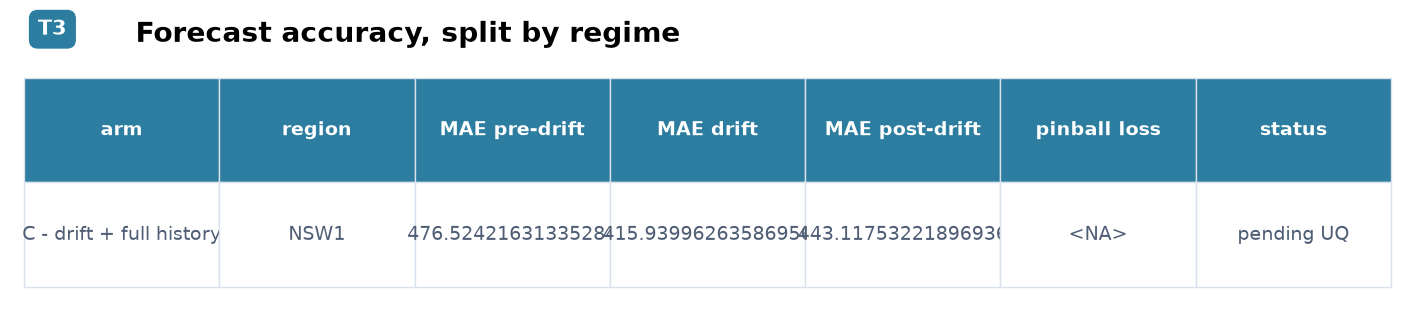

Saved to: table3_arm_c.png


In [42]:
# 严格按示例列顺序来
table3_arm_c_display = table3_arm_c[
    [
        "arm",
        "region",
        "mae_pre_drift",
        "mae_drift",
        "mae_post_drift",
        "pinball_loss",
        "pinball_status",
    ]
].copy()

# 改成示例里的列标题
table3_arm_c_display.columns = [
    "arm",
    "region",
    "MAE pre-drift",
    "MAE drift",
    "MAE post-drift",
    "pinball loss",
    "status",
]

render_table_image(
    df=table3_arm_c_display,
    tag="T3",
    title="Forecast accuracy, split by regime",
    output_path="table3_arm_c.png",
    fig_width=18,
    fig_height=4
)

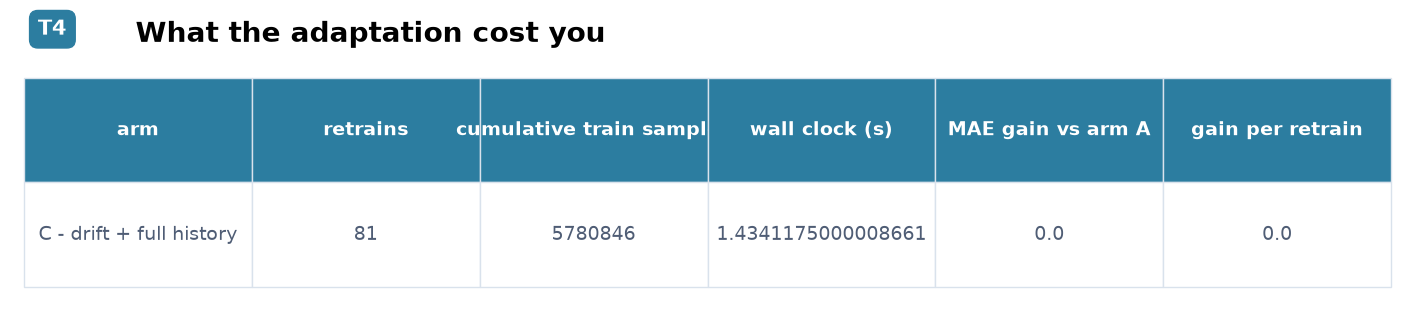

Saved to: table4_arm_c.png


In [43]:
# 严格按示例列顺序来
table4_arm_c_display = table4_arm_c[
    [
        "arm",
        "retrains",
        "cumulative_train_samples",
        "wall_clock_s",
        "mae_gain_vs_arm_a",
        "gain_per_retrain",
    ]
].copy()

# 改成示例里的列标题
table4_arm_c_display.columns = [
    "arm",
    "retrains",
    "cumulative train samples",
    "wall clock (s)",
    "MAE gain vs arm A",
    "gain per retrain",
]

render_table_image(
    df=table4_arm_c_display,
    tag="T4",
    title="What the adaptation cost you",
    output_path="table4_arm_c.png",
    fig_width=18,
    fig_height=4
)

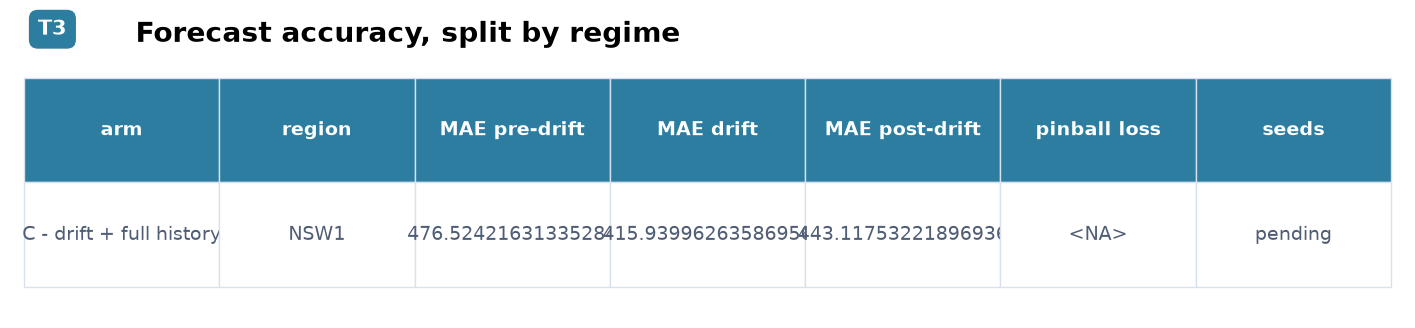

Saved to: table3_arm_c.png


In [44]:
table3_arm_c_display = table3_arm_c[
    [
        "arm",
        "region",
        "mae_pre_drift",
        "mae_drift",
        "mae_post_drift",
        "pinball_loss",
    ]
].copy()

table3_arm_c_display["seeds"] = "pending"

table3_arm_c_display.columns = [
    "arm",
    "region",
    "MAE pre-drift",
    "MAE drift",
    "MAE post-drift",
    "pinball loss",
    "seeds",
]

render_table_image(
    df=table3_arm_c_display,
    tag="T3",
    title="Forecast accuracy, split by regime",
    output_path="table3_arm_c.png",
    fig_width=18,
    fig_height=4
)

In [45]:
arm_c_curve = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.to_numpy(),
    "prediction": arm_c_pred.to_numpy(),
})

arm_c_curve["arm"] = "C"
arm_c_curve["region"] = REGION
arm_c_curve["model"] = "seasonal_naive"

arm_c_curve.head()

,timestamp,actual,prediction,arm,region,model
0,2020-03-01 00:00:00,7019.06,7146.84,C,NSW1,seasonal_naive
1,2020-03-01 00:30:00,6843.16,6991.19,C,NSW1,seasonal_naive
2,2020-03-01 01:00:00,6674.67,6783.37,C,NSW1,seasonal_naive
3,2020-03-01 01:30:00,6417.07,6503.91,C,NSW1,seasonal_naive
4,2020-03-01 02:00:00,6221.79,6347.40,C,NSW1,seasonal_naive


In [46]:
arm_c_retrains = pd.DataFrame(retrain_log).copy()

arm_c_retrains["arm"] = "C"
arm_c_retrains["region"] = REGION
arm_c_retrains["model"] = "seasonal_naive"

arm_c_retrains.head()

,alarm_day,history_rows,retrain_count,arm,region,model
0,2020-03-02,38015,1,C,NSW1,seasonal_naive
1,2020-03-20,38879,2,C,NSW1,seasonal_naive
2,2020-04-06,39695,3,C,NSW1,seasonal_naive
3,2020-04-21,40415,4,C,NSW1,seasonal_naive
4,2020-05-08,41231,5,C,NSW1,seasonal_naive


In [47]:
print("Curve rows:", len(arm_c_curve))
print("Retrain events:", len(arm_c_retrains))
print("First retrain:", arm_c_retrains["alarm_day"].min())
print("Last retrain:", arm_c_retrains["alarm_day"].max())

Curve rows: 67249
Retrain events: 81
First retrain: 2020-03-02 00:00:00
Last retrain: 2023-12-19 00:00:00


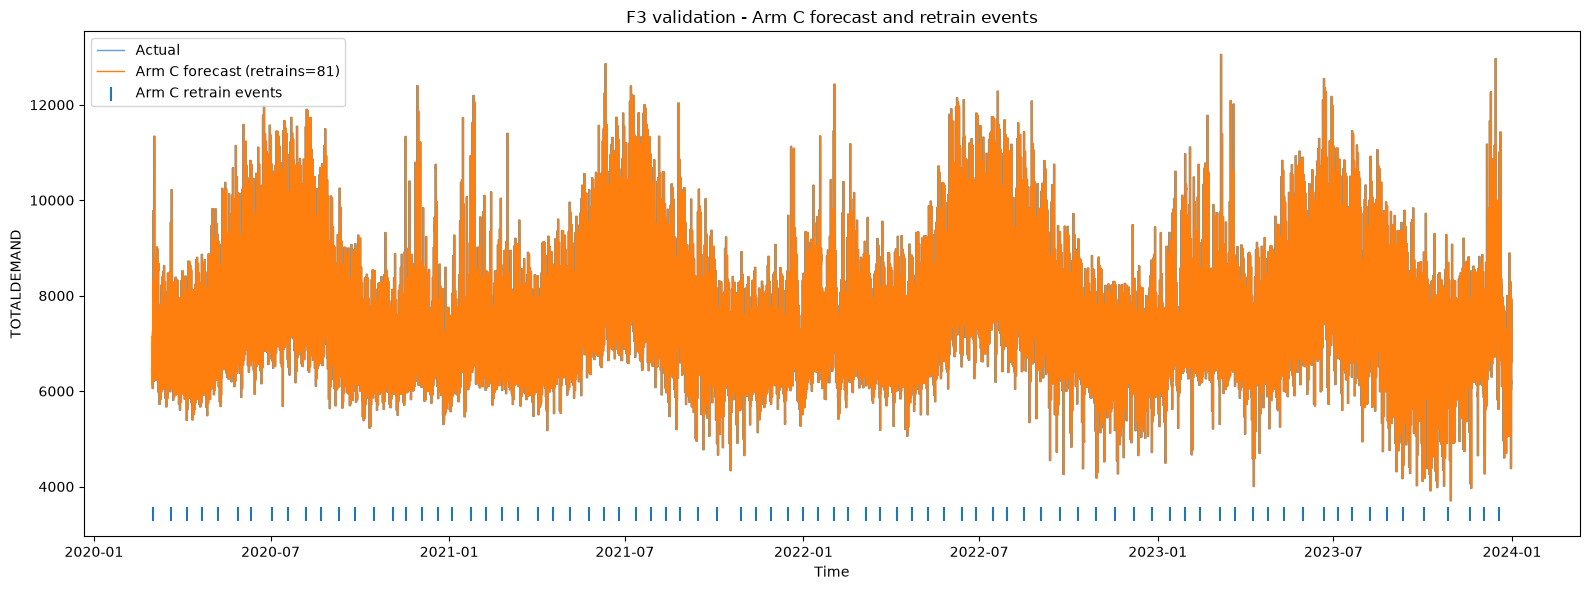

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))

# Actual demand
ax.plot(
    arm_c_curve["timestamp"],
    arm_c_curve["actual"],
    label="Actual",
    linewidth=1.0,
    alpha=0.7,
)

# Arm C forecast
ax.plot(
    arm_c_curve["timestamp"],
    arm_c_curve["prediction"],
    label=f"Arm C forecast (retrains={len(arm_c_retrains)})",
    linewidth=1.0,
)

# Retrain rug at the bottom
ymin, ymax = ax.get_ylim()
rug_y = ymin + 0.02 * (ymax - ymin)

ax.scatter(
    arm_c_retrains["alarm_day"],
    [rug_y] * len(arm_c_retrains),
    marker="|",
    s=100,
    label="Arm C retrain events",
)

ax.set_title("F3 validation - Arm C forecast and retrain events")
ax.set_xlabel("Time")
ax.set_ylabel("TOTALDEMAND")
ax.legend()

plt.tight_layout()
plt.show()

In [49]:
arm_a_curve = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.to_numpy(),
    "prediction": arm_a_pred,
})

arm_a_curve["arm"] = "A"
arm_a_curve["region"] = REGION
arm_a_curve["model"] = "seasonal_naive"

print("Arm A rows:", len(arm_a_curve))
print("Missing predictions:", arm_a_curve["prediction"].isna().sum())

arm_a_curve.head()

Arm A rows: 67249
Missing predictions: 0


,timestamp,actual,prediction,arm,region,model
0,2020-03-01 00:00:00,7019.06,7146.84,A,NSW1,seasonal_naive
1,2020-03-01 00:30:00,6843.16,6991.19,A,NSW1,seasonal_naive
2,2020-03-01 01:00:00,6674.67,6783.37,A,NSW1,seasonal_naive
3,2020-03-01 01:30:00,6417.07,6503.91,A,NSW1,seasonal_naive
4,2020-03-01 02:00:00,6221.79,6347.40,A,NSW1,seasonal_naive


In [50]:
arm_a_retrains = pd.DataFrame(
    columns=["alarm_day", "arm", "region", "model"]
)

print("Arm A retrains:", len(arm_a_retrains))

Arm A retrains: 0


In [51]:
def retrain_recent_3_months(model, history):
    """
    Arm D:
    retrain using the most recent 3 calendar months
    of available observations.
    """

    end_time = history.index.max()
    start_time = end_time - pd.DateOffset(months=3)

    recent = history[
        (history.index > start_time)
        & (history.index <= end_time)
    ]

    y = recent[TARGET_COLUMN]
    X = pd.DataFrame(index=recent.index)

    model.fit(X, y)

    return model, len(recent), start_time, end_time

In [52]:
first_alarm_day = accepted_days[0]

segment_end = (
    first_alarm_day
    + pd.Timedelta(days=1)
    - pd.Timedelta(minutes=30)
)

history_d = pd.concat(
    [train_y, cal_y]
).sort_index().to_frame()

first_segment_d = test_y[
    (test_y.index >= test_y.index.min())
    & (test_y.index <= segment_end)
]

history_d = pd.concat(
    [history_d, first_segment_d.to_frame()]
).sort_index()

test_model_d = SeasonalNaive()

test_model_d.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)

test_model_d.observe(cal_y)
test_model_d.observe(first_segment_d)

test_model_d, recent_rows, window_start, window_end = (
    retrain_recent_3_months(
        test_model_d,
        history_d
    )
)

print("Full history rows:", len(history_d))
print("Rows used for Arm D retrain:", recent_rows)
print("Window start:", window_start)
print("Window end:", window_end)

Full history rows: 38015
Rows used for Arm D retrain: 4368
Window start: 2019-12-02 23:30:00
Window end: 2020-03-02 23:30:00


In [53]:
start_time_d = time.perf_counter()

# 重新初始化 Arm D
model_d = SeasonalNaive()

model_d.fit(
    pd.DataFrame(index=train_y.index),
    train_y
)

model_d.observe(cal_y)

history_d = pd.concat(
    [train_y, cal_y]
).sort_index().to_frame()

arm_d_retrain_count = 0
arm_d_predictions = []
arm_d_retrain_log = []

current_start_d = test_y.index.min()

print("Arm D reset complete")
print("Start:", current_start_d)
print("Accepted alarm days:", len(accepted_days))

Arm D reset complete
Start: 2020-03-01 00:00:00
Accepted alarm days: 81


In [54]:
for alarm_day in accepted_days:
    segment_end = (
        alarm_day
        + pd.Timedelta(days=1)
        - pd.Timedelta(minutes=30)
    )

    segment_y = test_y[
        (test_y.index >= current_start_d)
        & (test_y.index <= segment_end)
    ]

    if len(segment_y) == 0:
        continue

    # 预测当前 segment
    segment_X = pd.DataFrame(
        {TARGET_COLUMN: segment_y.to_numpy()},
        index=segment_y.index,
    )

    segment_pred = model_d.predict(segment_X)

    arm_d_predictions.append(
        pd.Series(
            segment_pred,
            index=segment_y.index
        )
    )

    # reveal actual observations
    model_d.observe(segment_y)

    # 更新完整 history
    history_d = pd.concat(
        [history_d, segment_y.to_frame()]
    ).sort_index()

    # Arm D:
    # 只用最近 3 calendar months retrain
    model_d, recent_rows, window_start, window_end = (
        retrain_recent_3_months(
            model_d,
            history_d
        )
    )

    arm_d_retrain_count += 1

    arm_d_retrain_log.append({
        "alarm_day": alarm_day,
        "window_start": window_start,
        "window_end": window_end,
        "train_rows": recent_rows,
        "retrain_count": arm_d_retrain_count,
    })

    # 新模型从 d+1 开始
    current_start_d = (
        segment_end
        + pd.Timedelta(minutes=30)
    )

In [55]:
remaining_y_d = test_y[
    test_y.index >= current_start_d
]

if len(remaining_y_d) > 0:
    remaining_X_d = pd.DataFrame(
        {TARGET_COLUMN: remaining_y_d.to_numpy()},
        index=remaining_y_d.index,
    )

    remaining_pred_d = model_d.predict(
        remaining_X_d
    )

    arm_d_predictions.append(
        pd.Series(
            remaining_pred_d,
            index=remaining_y_d.index
        )
    )

    model_d.observe(remaining_y_d)

In [56]:
arm_d_pred = pd.concat(
    arm_d_predictions
).sort_index()

arm_d_pred = arm_d_pred.reindex(
    test_y.index
)

arm_d_wall_clock = (
    time.perf_counter()
    - start_time_d
)

print("Predictions:", len(arm_d_pred))
print("Expected:", len(test_y))
print(
    "Missing predictions:",
    arm_d_pred.isna().sum()
)
print(
    "Retrain count:",
    arm_d_retrain_count
)
print(
    "Arm D wall clock (s):",
    arm_d_wall_clock
)

Predictions: 67249
Expected: 67249
Missing predictions: 0
Retrain count: 81
Arm D wall clock (s): 24.894947499997215


In [57]:
arm_d_mae = calculate_mae(
    test_y.to_numpy(),
    arm_d_pred.to_numpy(),
)

print("Arm D overall MAE:", arm_d_mae)

Arm D overall MAE: 442.2665021784711


In [58]:
eval_d_df = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.to_numpy(),
    "prediction": arm_d_pred.to_numpy(),
})

eval_d_df = eval_d_df.merge(
    regime_df,
    on="timestamp",
    how="left",
)

regime_mae_d = {}

for regime in ["pre_drift", "drift", "post_drift"]:
    part = eval_d_df[
        eval_d_df["regime"] == regime
    ]

    mae = calculate_mae(
        part["actual"].to_numpy(),
        part["prediction"].to_numpy(),
    )

    regime_mae_d[regime] = mae

    print(
        regime,
        "rows =", len(part),
        "MAE =", mae
    )

pre_drift rows = 5472 MAE = 476.52421631335284
drift rows = 8832 MAE = 415.93996263586956
post_drift rows = 52945 MAE = 443.11753221896936


In [59]:
arm_d_retrain_df = pd.DataFrame(
    arm_d_retrain_log
)

initial_train_samples = len(train_y)

arm_d_retrain_samples = (
    arm_d_retrain_df["train_rows"].sum()
)

arm_d_cumulative_train_samples = (
    initial_train_samples
    + arm_d_retrain_samples
)

print(
    "Initial training samples:",
    initial_train_samples
)

print(
    "Samples used across Arm D retrains:",
    arm_d_retrain_samples
)

print(
    "Arm D cumulative training samples:",
    arm_d_cumulative_train_samples
)

Initial training samples: 35039
Samples used across Arm D retrains: 354816
Arm D cumulative training samples: 389855


In [60]:
arm_d_gain_vs_a = (
    arm_a_mae - arm_d_mae
)

arm_d_gain_per_retrain = (
    arm_d_gain_vs_a
    / arm_d_retrain_count
)

print(
    "Arm A MAE:",
    arm_a_mae
)

print(
    "Arm D MAE:",
    arm_d_mae
)

print(
    "MAE gain vs Arm A:",
    arm_d_gain_vs_a
)

print(
    "Gain per retrain:",
    arm_d_gain_per_retrain
)

Arm A MAE: 442.2665021784711
Arm D MAE: 442.2665021784711
MAE gain vs Arm A: 0.0
Gain per retrain: 0.0


In [61]:
table3_arm_d = pd.DataFrame([{
    "arm": "D - drift + recent window",
    "model": "seasonal_naive",
    "region": REGION,
    "mae_pre_drift": regime_mae_d["pre_drift"],
    "mae_drift": regime_mae_d["drift"],
    "mae_post_drift": regime_mae_d["post_drift"],
    "pinball_loss": pd.NA,
    "pinball_status": "pending UQ",
}])

table3_arm_d

,arm,model,region,mae_pre_drift,mae_drift,mae_post_drift,pinball_loss,pinball_status
0,D - drift + recent window,seasonal_naive,NSW1,476.524216,415.939963,443.117532,<NA>,pending UQ


In [62]:
table4_arm_d = pd.DataFrame([{
    "arm": "D - drift + recent window",
    "model": "seasonal_naive",
    "region": REGION,
    "retrains": arm_d_retrain_count,
    "cumulative_train_samples": arm_d_cumulative_train_samples,
    "wall_clock_s": arm_d_wall_clock,
    "arm_a_mae": arm_a_mae,
    "arm_d_mae": arm_d_mae,
    "mae_gain_vs_arm_a": arm_d_gain_vs_a,
    "gain_per_retrain": arm_d_gain_per_retrain,
}])

table4_arm_d

,arm,model,region,retrains,cumulative_train_samples,wall_clock_s,arm_a_mae,arm_d_mae,mae_gain_vs_arm_a,gain_per_retrain
0,D - drift + recent window,seasonal_naive,NSW1,81,389855,24.894947,442.266502,442.266502,0.0,0.0


In [63]:
table3_cd = pd.concat(
    [table3_arm_c, table3_arm_d],
    ignore_index=True
)

table4_cd = pd.concat(
    [table4_arm_c, table4_arm_d],
    ignore_index=True
)

display(table3_cd)
display(table4_cd)

,arm,model,region,mae_pre_drift,mae_drift,mae_post_drift,pinball_loss,pinball_status
0,C - drift + full history,seasonal_naive,NSW1,476.524216,415.939963,443.117532,<NA>,pending UQ
1,D - drift + recent window,seasonal_naive,NSW1,476.524216,415.939963,443.117532,<NA>,pending UQ


,arm,model,region,retrains,cumulative_train_samples,wall_clock_s,arm_a_mae,arm_c_mae,mae_gain_vs_arm_a,gain_per_retrain,arm_d_mae
0,C - drift + full history,seasonal_naive,NSW1,81,5780846,1.434118,442.266502,442.266502,0.0,0.0,NaN
1,D - drift + recent window,seasonal_naive,NSW1,81,389855,24.894947,442.266502,NaN,0.0,0.0,442.266502


In [64]:
table4_cd_clean = pd.DataFrame([
    {
        "arm": "C - drift + full history",
        "retrains": retrain_count,
        "cumulative train samples": cumulative_train_samples,
        "wall clock (s)": round(arm_c_wall_clock, 2),
        "MAE gain vs arm A": round(arm_a_mae - arm_c_mae, 2),
        "gain per retrain": round(
            (arm_a_mae - arm_c_mae) / retrain_count,
            2
        ),
    },
    {
        "arm": "D - drift + recent window",
        "retrains": arm_d_retrain_count,
        "cumulative train samples": arm_d_cumulative_train_samples,
        "wall clock (s)": round(arm_d_wall_clock, 2),
        "MAE gain vs arm A": round(arm_d_gain_vs_a, 2),
        "gain per retrain": round(arm_d_gain_per_retrain, 2),
    },
])

table4_cd_clean

,arm,retrains,cumulative train samples,wall clock (s),MAE gain vs arm A,gain per retrain
0,C - drift + full history,81,5780846,1.43,0.0,0.0
1,D - drift + recent window,81,389855,24.89,0.0,0.0


In [65]:
table3_cd_clean = pd.DataFrame([
    {
        "arm": "C - drift + full history",
        "region": REGION,
        "MAE pre-drift": round(regime_mae["pre_drift"], 2),
        "MAE drift": round(regime_mae["drift"], 2),
        "MAE post-drift": round(regime_mae["post_drift"], 2),
        "pinball loss": "Pending UQ",
        "seeds": "Pending",
    },
    {
        "arm": "D - drift + recent window",
        "region": REGION,
        "MAE pre-drift": round(regime_mae_d["pre_drift"], 2),
        "MAE drift": round(regime_mae_d["drift"], 2),
        "MAE post-drift": round(regime_mae_d["post_drift"], 2),
        "pinball loss": "Pending UQ",
        "seeds": "Pending",
    },
])

table3_cd_clean

,arm,region,MAE pre-drift,MAE drift,MAE post-drift,pinball loss,seeds
0,C - drift + full history,NSW1,476.52,415.94,443.12,Pending UQ,Pending
1,D - drift + recent window,NSW1,476.52,415.94,443.12,Pending UQ,Pending


In [66]:
arm_d_curve = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.to_numpy(),
    "prediction": arm_d_pred.to_numpy(),
})

arm_d_curve["arm"] = "D"
arm_d_curve["region"] = REGION
arm_d_curve["model"] = "seasonal_naive"

arm_d_curve.head()

,timestamp,actual,prediction,arm,region,model
0,2020-03-01 00:00:00,7019.06,7146.84,D,NSW1,seasonal_naive
1,2020-03-01 00:30:00,6843.16,6991.19,D,NSW1,seasonal_naive
2,2020-03-01 01:00:00,6674.67,6783.37,D,NSW1,seasonal_naive
3,2020-03-01 01:30:00,6417.07,6503.91,D,NSW1,seasonal_naive
4,2020-03-01 02:00:00,6221.79,6347.40,D,NSW1,seasonal_naive


In [67]:
arm_d_retrains = pd.DataFrame(
    arm_d_retrain_log
).copy()

arm_d_retrains["arm"] = "D"
arm_d_retrains["region"] = REGION
arm_d_retrains["model"] = "seasonal_naive"

arm_d_retrains.head()

,alarm_day,window_start,window_end,train_rows,retrain_count,arm,region,model
0,2020-03-02,2019-12-02 23:30:00,2020-03-02 23:30:00,4368,1,D,NSW1,seasonal_naive
1,2020-03-20,2019-12-20 23:30:00,2020-03-20 23:30:00,4368,2,D,NSW1,seasonal_naive
2,2020-04-06,2020-01-06 23:30:00,2020-04-06 23:30:00,4368,3,D,NSW1,seasonal_naive
3,2020-04-21,2020-01-21 23:30:00,2020-04-21 23:30:00,4368,4,D,NSW1,seasonal_naive
4,2020-05-08,2020-02-08 23:30:00,2020-05-08 23:30:00,4320,5,D,NSW1,seasonal_naive


In [68]:
print("Arm D curve rows:", len(arm_d_curve))
print("Arm D retrain events:", len(arm_d_retrains))
print("First D retrain:", arm_d_retrains["alarm_day"].min())
print("Last D retrain:", arm_d_retrains["alarm_day"].max())

Arm D curve rows: 67249
Arm D retrain events: 81
First D retrain: 2020-03-02 00:00:00
Last D retrain: 2023-12-19 00:00:00


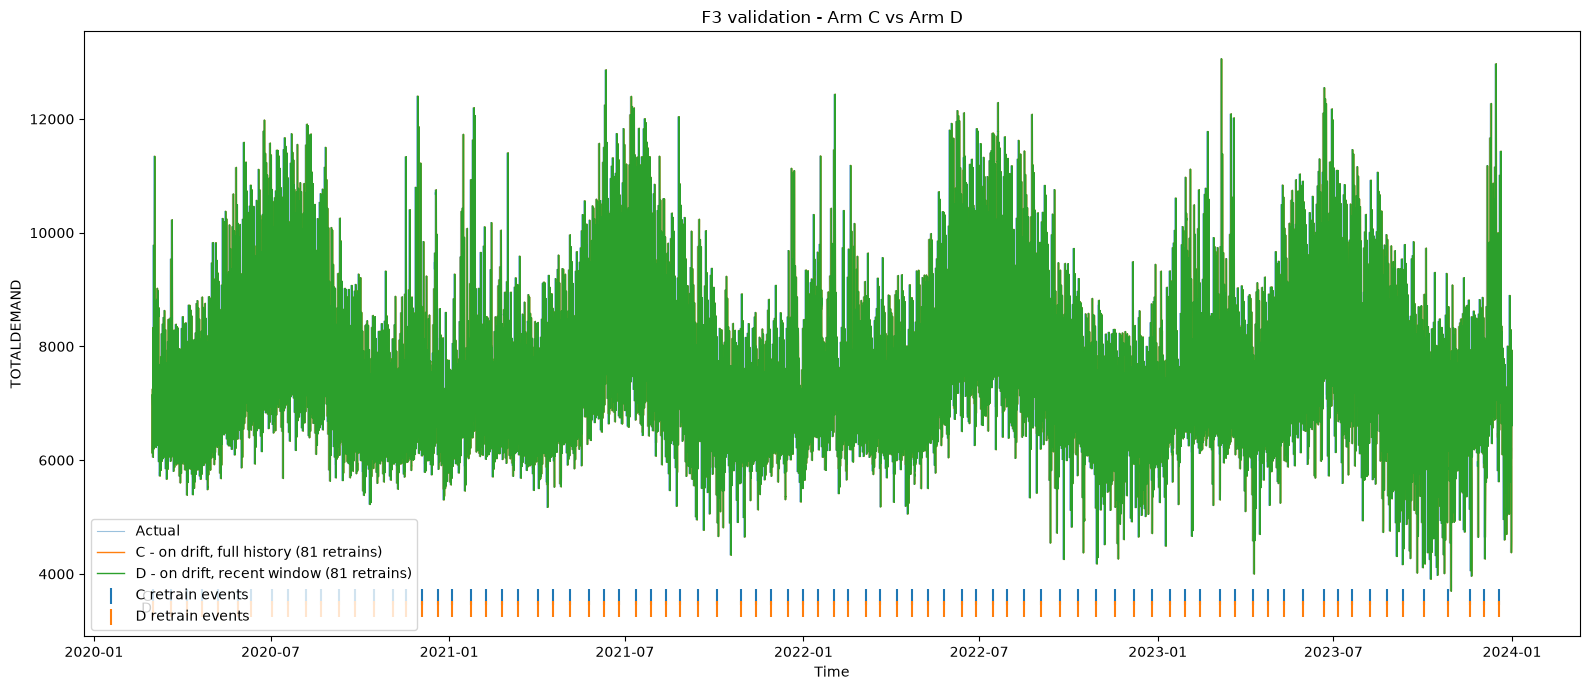

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))

# Actual demand
ax.plot(
    arm_c_curve["timestamp"],
    arm_c_curve["actual"],
    label="Actual",
    linewidth=0.8,
    alpha=0.45,
)

# Arm C
ax.plot(
    arm_c_curve["timestamp"],
    arm_c_curve["prediction"],
    label=f"C - on drift, full history ({len(arm_c_retrains)} retrains)",
    linewidth=1.0,
)

# Arm D
ax.plot(
    arm_d_curve["timestamp"],
    arm_d_curve["prediction"],
    label=f"D - on drift, recent window ({len(arm_d_retrains)} retrains)",
    linewidth=1.0,
)

# 当前 y 轴范围
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

# 两行 retrain rug
c_rug_y = ymin + 0.035 * yrange
d_rug_y = ymin + 0.015 * yrange

ax.scatter(
    arm_c_retrains["alarm_day"],
    [c_rug_y] * len(arm_c_retrains),
    marker="|",
    s=120,
    label="C retrain events",
)

ax.scatter(
    arm_d_retrains["alarm_day"],
    [d_rug_y] * len(arm_d_retrains),
    marker="|",
    s=120,
    label="D retrain events",
)

# 标签
ax.text(
    arm_c_curve["timestamp"].min(),
    c_rug_y,
    "C",
    va="center",
    ha="right",
)

ax.text(
    arm_d_curve["timestamp"].min(),
    d_rug_y,
    "D",
    va="center",
    ha="right",
)

ax.set_title("F3 validation - Arm C vs Arm D")
ax.set_xlabel("Time")
ax.set_ylabel("TOTALDEMAND")
ax.legend()

plt.tight_layout()
plt.show()

In [70]:
arm_c_rolling_mae = calculate_rolling_mae(
    test_y.to_numpy(),
    arm_c_pred.to_numpy(),
)

arm_d_rolling_mae = calculate_rolling_mae(
    test_y.to_numpy(),
    arm_d_pred.to_numpy(),
)

print("Arm C rolling MAE valid:", arm_c_rolling_mae.notna().sum())
print("Arm D rolling MAE valid:", arm_d_rolling_mae.notna().sum())

print("Arm C first valid:", arm_c_rolling_mae.first_valid_index())
print("Arm D first valid:", arm_d_rolling_mae.first_valid_index())

Arm C rolling MAE valid: 66914
Arm D rolling MAE valid: 66914
Arm C first valid: 335
Arm D first valid: 335


In [71]:
arm_c_rolling_curve = pd.DataFrame({
    "timestamp": test_y.index,
    "rolling_mae": arm_c_rolling_mae.to_numpy(),
})

arm_d_rolling_curve = pd.DataFrame({
    "timestamp": test_y.index,
    "rolling_mae": arm_d_rolling_mae.to_numpy(),
})

display(arm_c_rolling_curve.head(340).tail())
display(arm_d_rolling_curve.head(340).tail())

,timestamp,rolling_mae
335,2020-03-07 23:30:00,553.586131
336,2020-03-08 00:00:00,554.459196
337,2020-03-08 00:30:00,555.101696
338,2020-03-08 01:00:00,555.796190
339,2020-03-08 01:30:00,556.432321


,timestamp,rolling_mae
335,2020-03-07 23:30:00,553.586131
336,2020-03-08 00:00:00,554.459196
337,2020-03-08 00:30:00,555.101696
338,2020-03-08 01:00:00,555.796190
339,2020-03-08 01:30:00,556.432321


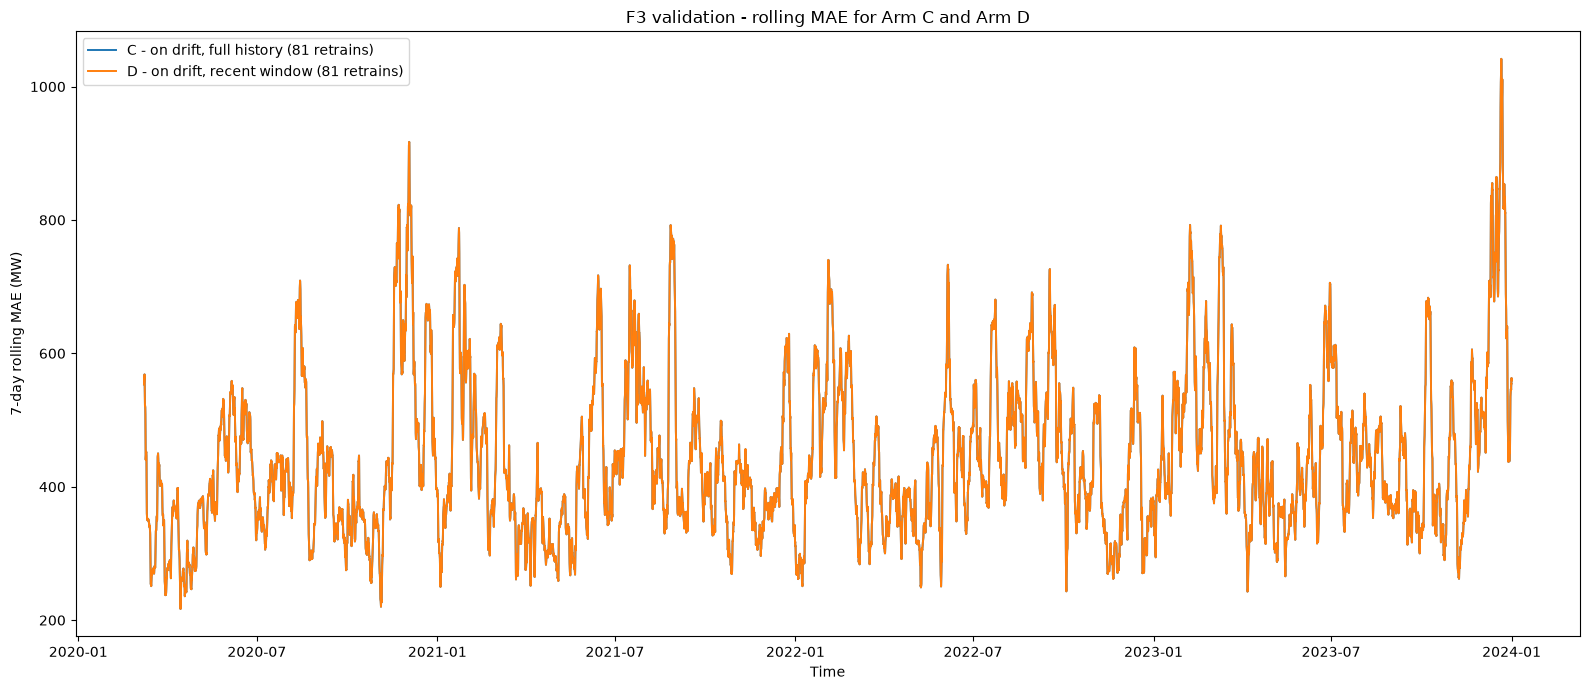

In [72]:
fig, ax = plt.subplots(figsize=(16, 7))

# Arm C rolling MAE
ax.plot(
    arm_c_rolling_curve["timestamp"],
    arm_c_rolling_curve["rolling_mae"],
    label=f"C - on drift, full history ({len(arm_c_retrains)} retrains)",
    linewidth=1.4,
)

# Arm D rolling MAE
ax.plot(
    arm_d_rolling_curve["timestamp"],
    arm_d_rolling_curve["rolling_mae"],
    label=f"D - on drift, recent window ({len(arm_d_retrains)} retrains)",
    linewidth=1.4,
)

ax.set_title("F3 validation - rolling MAE for Arm C and Arm D")
ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.legend()

plt.tight_layout()
plt.show()

In [73]:
test_start = test_y.index.min()
test_end = test_y.index.max()

f3_drift_windows = event_windows[
    (event_windows["drift_end"] >= test_start)
    & (event_windows["drift_start"] <= test_end)
].copy()

print("Drift windows in test period:", len(f3_drift_windows))

f3_drift_windows[
    ["event_id", "drift_start", "drift_end"]
].head(20)

Drift windows in test period: 19


,event_id,drift_start,drift_end
1,EVT-2020-02,2020-03-16,2020-05-18
2,EVT-2020-04,2020-08-29,2020-08-30
3,EVT-2020-07,2020-12-01,2021-01-01
4,EVT-2021-08,2021-06-10,2021-06-11
5,EVT-2021-02,2021-08-01,2021-09-01
6,EVT-2021-03,2021-09-19,2021-09-20
7,EVT-2021-05,2021-10-17,2021-10-18
8,EVT-2022-02,2022-06-07,2022-06-13
9,EVT-2022-03,2022-06-15,2022-06-25
10,EVT-2022-04,2022-08-28,2022-08-29


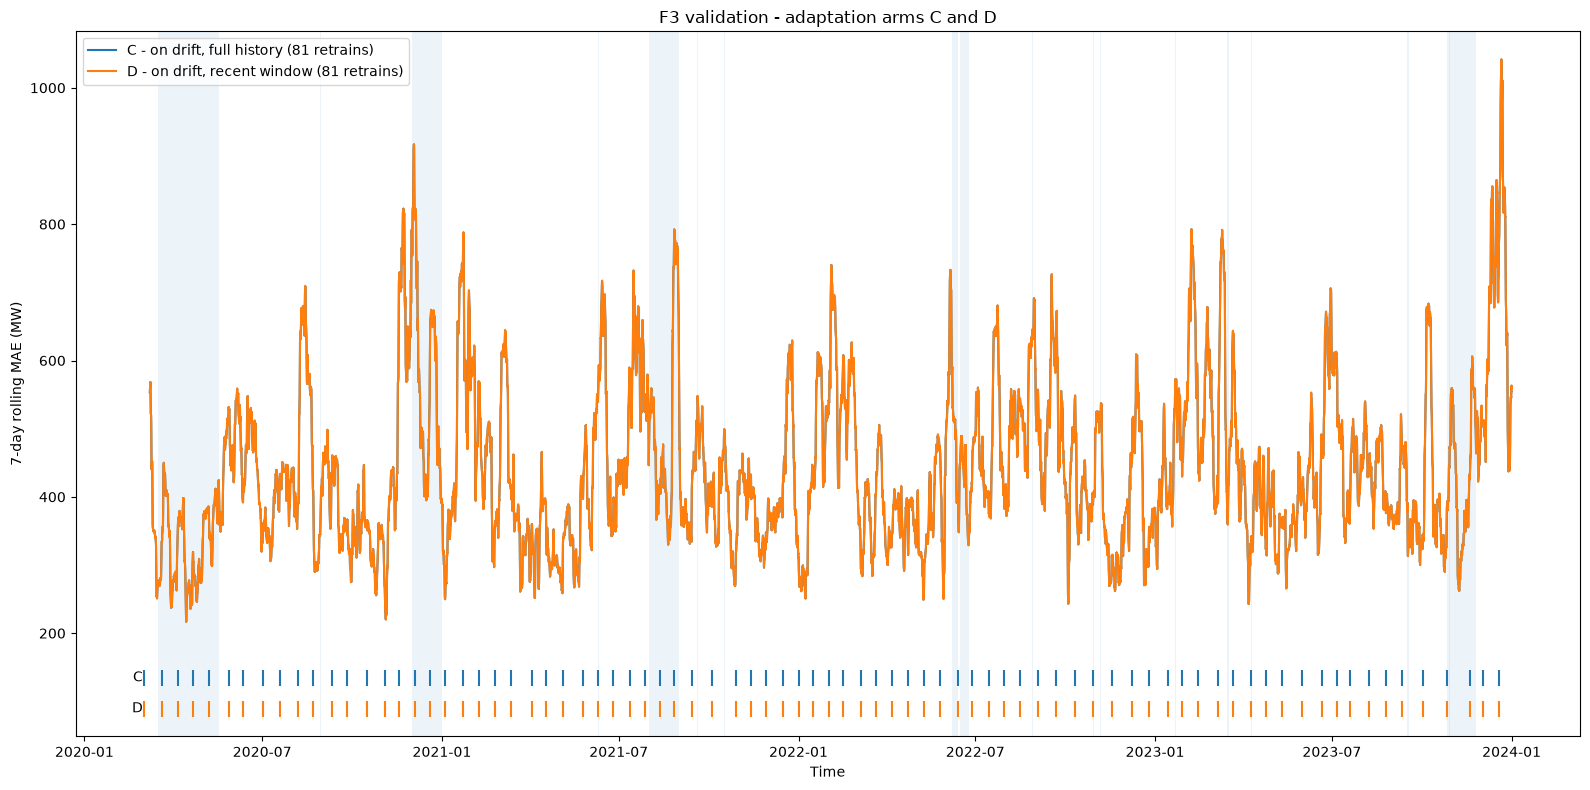

In [74]:
fig, ax = plt.subplots(figsize=(16, 8))

# -------------------------
# C / D rolling MAE
# -------------------------

ax.plot(
    arm_c_rolling_curve["timestamp"],
    arm_c_rolling_curve["rolling_mae"],
    label=f"C - on drift, full history ({len(arm_c_retrains)} retrains)",
    linewidth=1.5,
)

ax.plot(
    arm_d_rolling_curve["timestamp"],
    arm_d_rolling_curve["rolling_mae"],
    label=f"D - on drift, recent window ({len(arm_d_retrains)} retrains)",
    linewidth=1.5,
)

# -------------------------
# Drift periods
# -------------------------

for _, row in f3_drift_windows.iterrows():
    ax.axvspan(
        row["drift_start"],
        row["drift_end"],
        alpha=0.08,
    )

# -------------------------
# Leave space for retrain rugs
# -------------------------

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

ax.set_ylim(
    ymin - 0.14 * yrange,
    ymax
)

c_rug_y = ymin - 0.045 * yrange
d_rug_y = ymin - 0.095 * yrange

# C retrain row
ax.scatter(
    arm_c_retrains["alarm_day"],
    [c_rug_y] * len(arm_c_retrains),
    marker="|",
    s=130,
)

# D retrain row
ax.scatter(
    arm_d_retrains["alarm_day"],
    [d_rug_y] * len(arm_d_retrains),
    marker="|",
    s=130,
)

# Row labels
ax.text(
    test_start,
    c_rug_y,
    "C",
    ha="right",
    va="center",
)

ax.text(
    test_start,
    d_rug_y,
    "D",
    ha="right",
    va="center",
)

# -------------------------
# Labels
# -------------------------

ax.set_title(
    "F3 validation - adaptation arms C and D"
)

ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.legend()

plt.tight_layout()
plt.show()

In [75]:
baseline_mask = (
    regime_df["regime"].to_numpy()
    == "pre_drift"
)

baseline_values = (
    arm_c_rolling_mae[baseline_mask]
    .dropna()
)

pre_drift_baseline = baseline_values.mean()

print(
    "Pre-drift baseline:",
    pre_drift_baseline
)

print(
    "Baseline samples:",
    len(baseline_values)
)

Pre-drift baseline: 461.0926448109931
Baseline samples: 5472


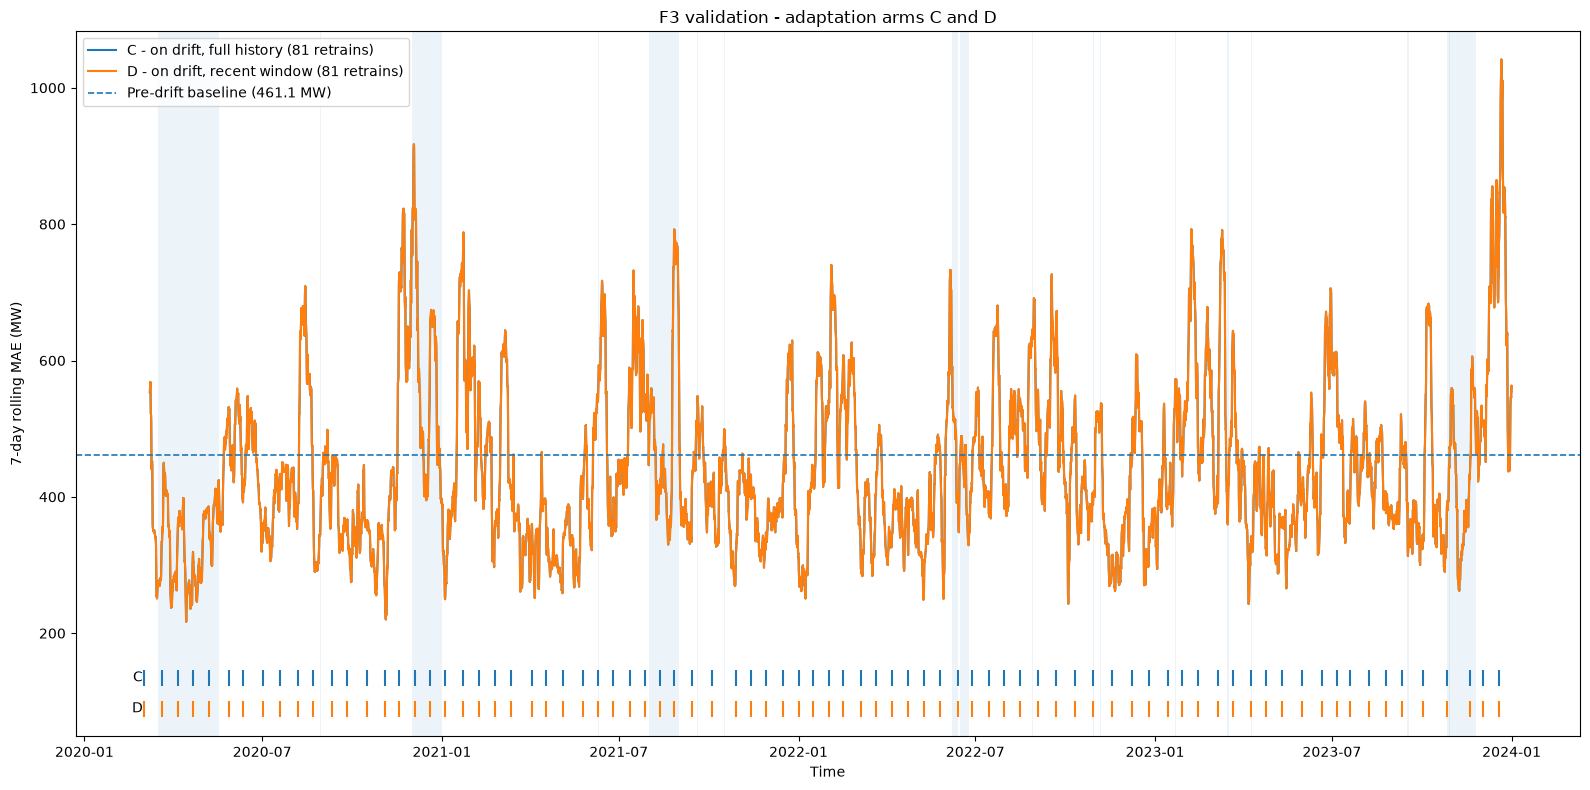

In [76]:
fig, ax = plt.subplots(figsize=(16, 8))

# -------------------------
# C / D rolling MAE
# -------------------------

ax.plot(
    arm_c_rolling_curve["timestamp"],
    arm_c_rolling_curve["rolling_mae"],
    label=f"C - on drift, full history ({len(arm_c_retrains)} retrains)",
    linewidth=1.5,
)

ax.plot(
    arm_d_rolling_curve["timestamp"],
    arm_d_rolling_curve["rolling_mae"],
    label=f"D - on drift, recent window ({len(arm_d_retrains)} retrains)",
    linewidth=1.5,
)

# -------------------------
# Drift periods
# -------------------------

for _, row in f3_drift_windows.iterrows():
    ax.axvspan(
        row["drift_start"],
        row["drift_end"],
        alpha=0.08,
    )

# -------------------------
# Leave space for retrain rugs
# -------------------------

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

ax.set_ylim(
    ymin - 0.14 * yrange,
    ymax
)

c_rug_y = ymin - 0.045 * yrange
d_rug_y = ymin - 0.095 * yrange

# C retrain row
ax.scatter(
    arm_c_retrains["alarm_day"],
    [c_rug_y] * len(arm_c_retrains),
    marker="|",
    s=130,
)

# D retrain row
ax.scatter(
    arm_d_retrains["alarm_day"],
    [d_rug_y] * len(arm_d_retrains),
    marker="|",
    s=130,
)

# Row labels
ax.text(
    test_start,
    c_rug_y,
    "C",
    ha="right",
    va="center",
)

ax.text(
    test_start,
    d_rug_y,
    "D",
    ha="right",
    va="center",
)

# -------------------------
# Labels
# -------------------------

ax.set_title(
    "F3 validation - adaptation arms C and D"
)

ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.axhline(
    pre_drift_baseline,
    linestyle="--",
    linewidth=1.2,
    label=f"Pre-drift baseline ({pre_drift_baseline:.1f} MW)",
)
ax.legend()

plt.tight_layout()
plt.show()

In [78]:
from pathlib import Path
import pandas as pd

ISHAN_WORKTREE = Path(
    r"D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting\tmp_ishan_worktree"
)

arm_a_curve_path = (
    ISHAN_WORKTREE
    / "results"
    / "runs"
    / "0721a563132f"
    / "curve_aemo_NSW1_none.csv"
)

arm_b_curve_path = (
    ISHAN_WORKTREE
    / "results"
    / "runs"
    / "3438a1923f7b"
    / "curve_aemo_NSW1_none.csv"
)

arm_a_curve_raw = pd.read_csv(
    arm_a_curve_path,
    index_col=0,
    parse_dates=True
)

arm_b_curve_raw = pd.read_csv(
    arm_b_curve_path,
    index_col=0,
    parse_dates=True
)

print("Arm A shape:", arm_a_curve_raw.shape)
print("Arm B shape:", arm_b_curve_raw.shape)

display(arm_a_curve_raw.head())
display(arm_b_curve_raw.head())

Arm A shape: (67249, 1)
Arm B shape: (67249, 1)


,rolling_mae_7d
index,
2020-03-01 00:00:00,NaN
2020-03-01 00:30:00,NaN
2020-03-01 01:00:00,NaN
2020-03-01 01:30:00,NaN
2020-03-01 02:00:00,NaN


,rolling_mae_7d
index,
2020-03-01 00:00:00,NaN
2020-03-01 00:30:00,NaN
2020-03-01 01:00:00,NaN
2020-03-01 01:30:00,NaN
2020-03-01 02:00:00,NaN


In [79]:
arm_a_rolling_mae = arm_a_curve_raw["rolling_mae_7d"].copy()
arm_b_rolling_mae = arm_b_curve_raw["rolling_mae_7d"].copy()

print("A valid:", arm_a_rolling_mae.notna().sum())
print("B valid:", arm_b_rolling_mae.notna().sum())
print("C valid:", arm_c_rolling_mae.notna().sum())
print("D valid:", arm_d_rolling_mae.notna().sum())

print("A first valid:", arm_a_rolling_mae.first_valid_index())
print("B first valid:", arm_b_rolling_mae.first_valid_index())

print("A index == C index:", arm_a_rolling_mae.index.equals(test_y.index))
print("B index == C index:", arm_b_rolling_mae.index.equals(test_y.index))

A valid: 66914
B valid: 66914
C valid: 66914
D valid: 66914
A first valid: 2020-03-07 23:30:00
B first valid: 2020-03-07 23:30:00
A index == C index: True
B index == C index: True


Pre-drift baseline: 476.52421631335284


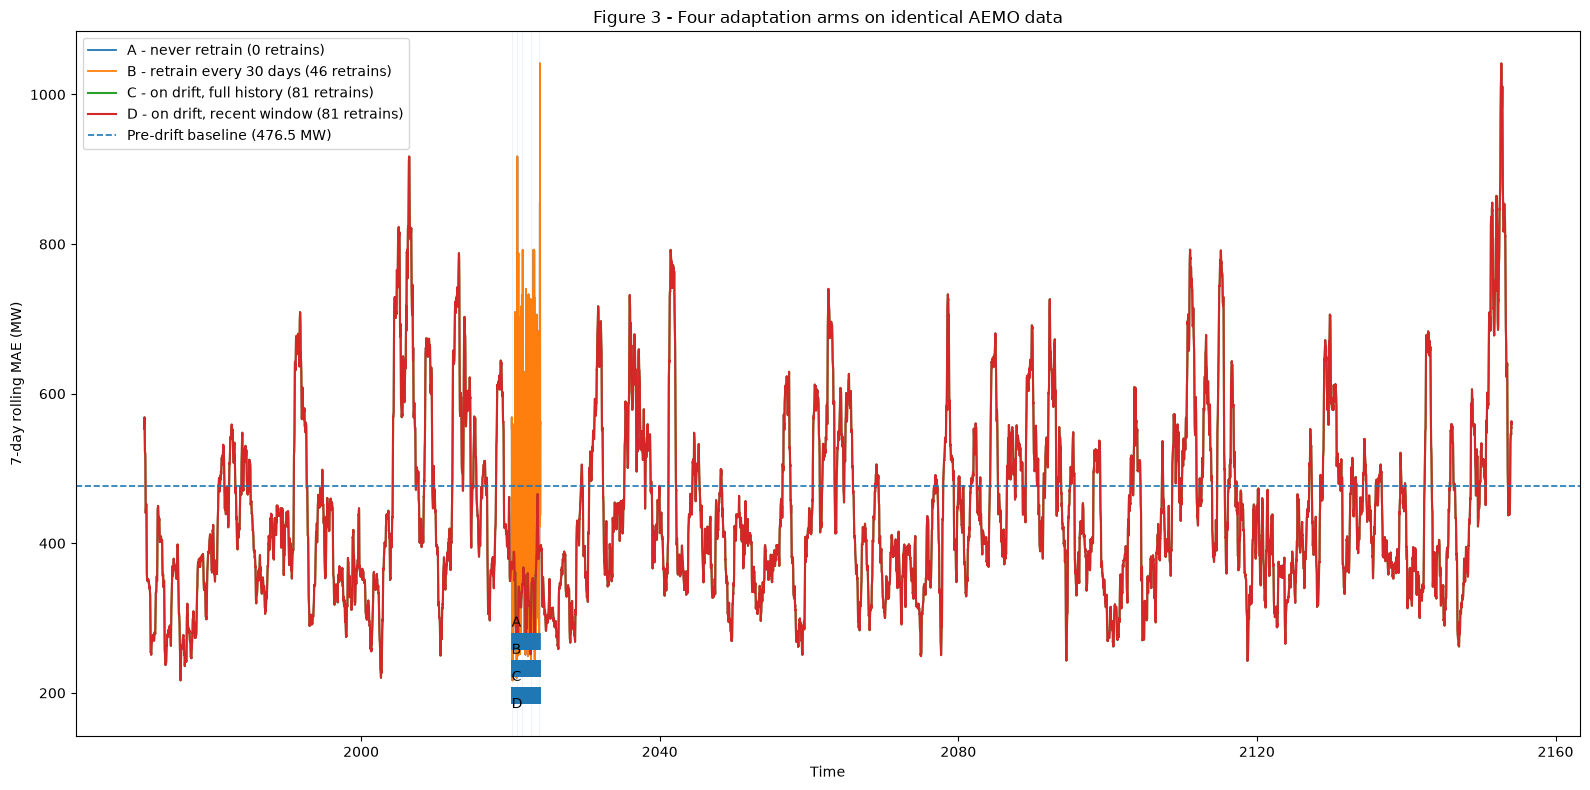

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Retrain counts
# -----------------------------
A_RETRAINS = 0
B_RETRAINS = 46
C_RETRAINS = len(arm_c_retrains)
D_RETRAINS = len(arm_d_retrains)

# -----------------------------
# Pre-drift baseline
# -----------------------------
pre_mask = regime_df["regime"] == "pre_drift"

pre_drift_baseline = calculate_mae(
    eval_df.loc[pre_mask, "actual"].to_numpy(),
    eval_df.loc[pre_mask, "prediction"].to_numpy(),
)

print("Pre-drift baseline:", pre_drift_baseline)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(
    arm_a_rolling_mae.index,
    arm_a_rolling_mae,
    label=f"A - never retrain ({A_RETRAINS} retrains)",
    linewidth=1.3,
)

ax.plot(
    arm_b_rolling_mae.index,
    arm_b_rolling_mae,
    label=f"B - retrain every 30 days ({B_RETRAINS} retrains)",
    linewidth=1.3,
)

ax.plot(
    arm_c_rolling_mae.index,
    arm_c_rolling_mae,
    label=f"C - on drift, full history ({C_RETRAINS} retrains)",
    linewidth=1.5,
)

ax.plot(
    arm_d_rolling_mae.index,
    arm_d_rolling_mae,
    label=f"D - on drift, recent window ({D_RETRAINS} retrains)",
    linewidth=1.5,
)

# -----------------------------
# Event windows
# -----------------------------
for _, row in event_windows.iterrows():
    ax.axvspan(
        row["drift_start"],
        row["drift_end"],
        alpha=0.08,
    )

# -----------------------------
# Pre-drift baseline
# -----------------------------
ax.axhline(
    pre_drift_baseline,
    linestyle="--",
    linewidth=1.2,
    label=f"Pre-drift baseline ({pre_drift_baseline:.1f} MW)",
)

# -----------------------------
# Retrain event rows
# -----------------------------
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

row_a = ymin + 0.13 * yrange
row_b = ymin + 0.09 * yrange
row_c = ymin + 0.05 * yrange
row_d = ymin + 0.01 * yrange

# Arm B: every 30-day retrain events
# Approximate dates directly from B's schedule
b_retrain_dates = pd.date_range(
    start=test_y.index.min() + pd.Timedelta(days=30),
    periods=B_RETRAINS,
    freq="30D",
)

for t in b_retrain_dates:
    ax.vlines(t, row_b, row_b + 0.025 * yrange, linewidth=1.2)

for t in pd.to_datetime(arm_c_retrains["alarm_day"]):
    ax.vlines(t, row_c, row_c + 0.025 * yrange, linewidth=1.2)

for t in pd.to_datetime(arm_d_retrains["alarm_day"]):
    ax.vlines(t, row_d, row_d + 0.025 * yrange, linewidth=1.2)

# A has zero retrains — no tick marks

ax.text(test_y.index.min(), row_a, "A", va="center")
ax.text(test_y.index.min(), row_b, "B", va="center")
ax.text(test_y.index.min(), row_c, "C", va="center")
ax.text(test_y.index.min(), row_d, "D", va="center")

# -----------------------------
# Labels
# -----------------------------
ax.set_title("Figure 3 - Four adaptation arms on identical AEMO data")
ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.legend()
plt.tight_layout()

plt.savefig(
    "figure3_four_adaptation_arms.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [81]:
print("A index type:", type(arm_a_rolling_mae.index))
print("B index type:", type(arm_b_rolling_mae.index))
print("C index type:", type(arm_c_rolling_mae.index))
print("D index type:", type(arm_d_rolling_mae.index))

print("A dtype:", arm_a_rolling_mae.index.dtype)
print("B dtype:", arm_b_rolling_mae.index.dtype)
print("C dtype:", arm_c_rolling_mae.index.dtype)
print("D dtype:", arm_d_rolling_mae.index.dtype)

print("A first:", arm_a_rolling_mae.index[0])
print("B first:", arm_b_rolling_mae.index[0])
print("C first:", arm_c_rolling_mae.index[0])
print("D first:", arm_d_rolling_mae.index[0])

A index type: <class 'pandas.DatetimeIndex'>
B index type: <class 'pandas.DatetimeIndex'>
C index type: <class 'pandas.RangeIndex'>
D index type: <class 'pandas.RangeIndex'>
A dtype: datetime64[us]
B dtype: datetime64[us]
C dtype: int64
D dtype: int64
A first: 2020-03-01 00:00:00
B first: 2020-03-01 00:00:00
C first: 0
D first: 0


In [82]:
import numpy as np

print(
    "A == B:",
    np.allclose(
        arm_a_rolling_mae.to_numpy(),
        arm_b_rolling_mae.to_numpy(),
        equal_nan=True
    )
)

print(
    "A == C:",
    np.allclose(
        arm_a_rolling_mae.to_numpy(),
        arm_c_rolling_mae.to_numpy(),
        equal_nan=True
    )
)

print(
    "C == D:",
    np.allclose(
        arm_c_rolling_mae.to_numpy(),
        arm_d_rolling_mae.to_numpy(),
        equal_nan=True
    )
)

A == B: True
A == C: True
C == D: True


In [83]:
arm_c_rolling_mae = pd.Series(
    arm_c_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d"
)

arm_d_rolling_mae = pd.Series(
    arm_d_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d"
)

print(type(arm_c_rolling_mae.index))
print(type(arm_d_rolling_mae.index))

print("C first:", arm_c_rolling_mae.index[0])
print("D first:", arm_d_rolling_mae.index[0])

<class 'pandas.DatetimeIndex'>
<class 'pandas.DatetimeIndex'>
C first: 2020-03-01 00:00:00
D first: 2020-03-01 00:00:00


In [84]:
print(
    "All indexes equal:",
    arm_a_rolling_mae.index.equals(arm_b_rolling_mae.index)
    and arm_a_rolling_mae.index.equals(arm_c_rolling_mae.index)
    and arm_a_rolling_mae.index.equals(arm_d_rolling_mae.index)
)

All indexes equal: True


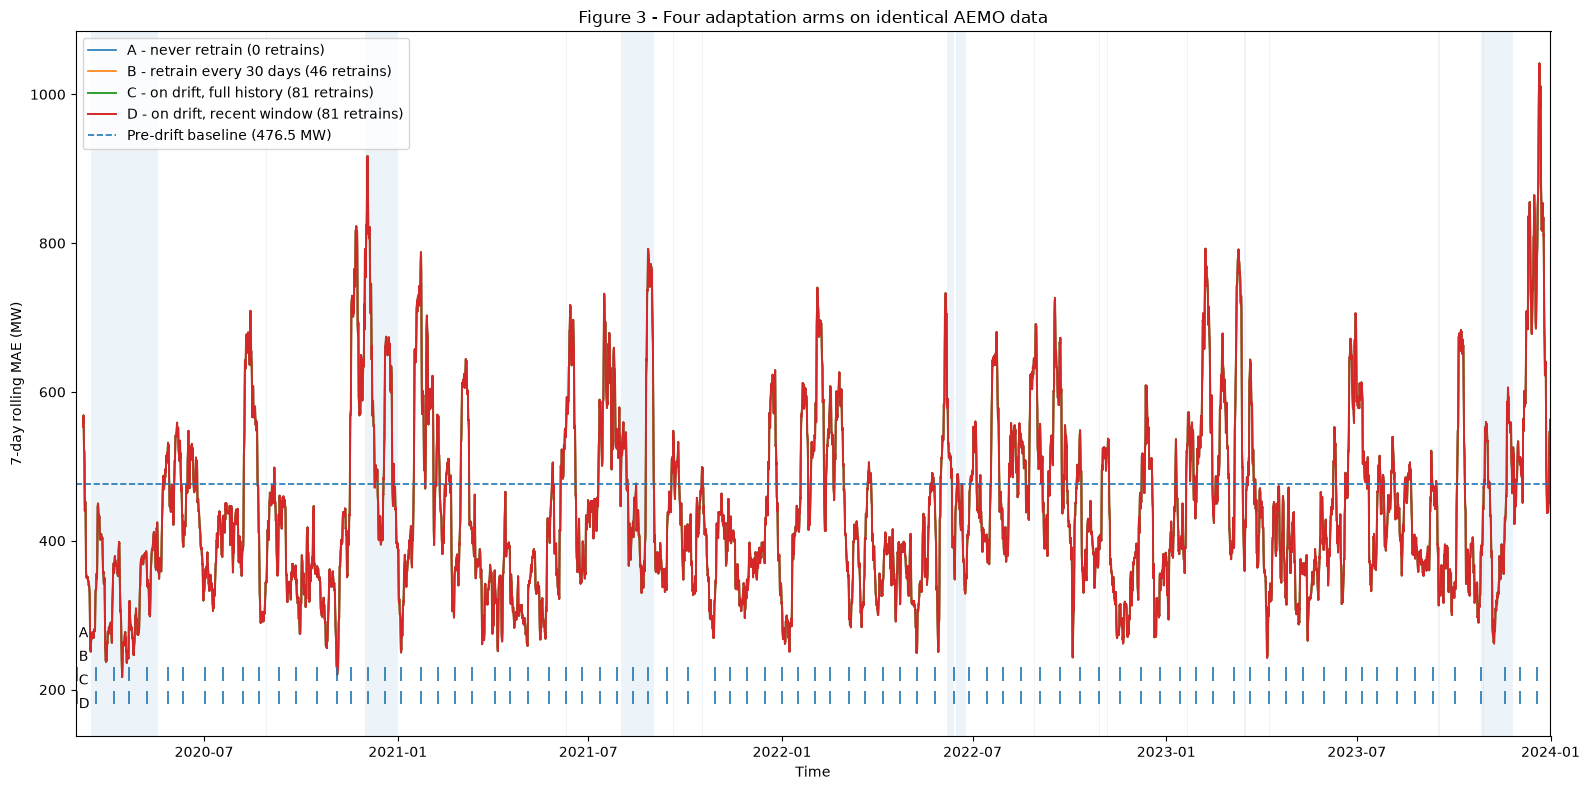

In [85]:
import matplotlib.pyplot as plt

A_RETRAINS = 0
B_RETRAINS = 46
C_RETRAINS = len(arm_c_retrains)
D_RETRAINS = len(arm_d_retrains)

fig, ax = plt.subplots(figsize=(16, 8))

# -----------------------------
# Four adaptation arms
# -----------------------------
ax.plot(
    arm_a_rolling_mae.index,
    arm_a_rolling_mae,
    label=f"A - never retrain ({A_RETRAINS} retrains)",
    linewidth=1.2,
)

ax.plot(
    arm_b_rolling_mae.index,
    arm_b_rolling_mae,
    label=f"B - retrain every 30 days ({B_RETRAINS} retrains)",
    linewidth=1.2,
)

ax.plot(
    arm_c_rolling_mae.index,
    arm_c_rolling_mae,
    label=f"C - on drift, full history ({C_RETRAINS} retrains)",
    linewidth=1.4,
)

ax.plot(
    arm_d_rolling_mae.index,
    arm_d_rolling_mae,
    label=f"D - on drift, recent window ({D_RETRAINS} retrains)",
    linewidth=1.4,
)

# -----------------------------
# Drift / documented event windows
# -----------------------------
for _, row in event_windows.iterrows():
    start = pd.to_datetime(row["drift_start"])
    end = pd.to_datetime(row["drift_end"])

    if end >= test_y.index.min() and start <= test_y.index.max():
        ax.axvspan(
            max(start, test_y.index.min()),
            min(end, test_y.index.max()),
            alpha=0.08,
        )

# -----------------------------
# Pre-drift baseline
# -----------------------------
ax.axhline(
    pre_drift_baseline,
    linestyle="--",
    linewidth=1.2,
    label=f"Pre-drift baseline ({pre_drift_baseline:.1f} MW)",
)

# -----------------------------
# Retrain event rows
# -----------------------------
ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

row_a = ymin + 0.11 * yrange
row_b = ymin + 0.075 * yrange
row_c = ymin + 0.040 * yrange
row_d = ymin + 0.005 * yrange

# Arm C
for t in pd.to_datetime(arm_c_retrains["alarm_day"]):
    ax.vlines(
        t,
        row_c,
        row_c + 0.02 * yrange,
        linewidth=1.2,
    )

# Arm D
for t in pd.to_datetime(arm_d_retrains["alarm_day"]):
    ax.vlines(
        t,
        row_d,
        row_d + 0.02 * yrange,
        linewidth=1.2,
    )

# labels
label_x = test_y.index.min() + pd.Timedelta(days=3)

ax.text(label_x, row_a, "A", va="center")
ax.text(label_x, row_b, "B", va="center")
ax.text(label_x, row_c, "C", va="center")
ax.text(label_x, row_d, "D", va="center")

# -----------------------------
# Final formatting
# -----------------------------
ax.set_xlim(test_y.index.min(), test_y.index.max())

ax.set_title("Figure 3 - Four adaptation arms on identical AEMO data")
ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [86]:
from pathlib import Path
import pandas as pd

arm_b_retrain_path = Path(
    r"D:\Projects\Detecting-and-Adapting-to-Concept-Drift-in-Time-Series-Forecasting"
    r"\tmp_ishan_worktree"
    r"\arm_b_retrain_dates_NSW1_seasonal_naive.csv"
)

arm_b_retrains = pd.read_csv(
    arm_b_retrain_path,
    parse_dates=["retrain_date"],
)

print("Arm B retrain events:", len(arm_b_retrains))
print("First:", arm_b_retrains["retrain_date"].min())
print("Last:", arm_b_retrains["retrain_date"].max())

arm_b_retrains.head()

Arm B retrain events: 46
First: 2020-03-30 23:30:00
Last: 2023-12-10 23:30:00


,retrain_date
0,2020-03-30 23:30:00
1,2020-04-29 23:30:00
2,2020-05-29 23:30:00
3,2020-06-28 23:30:00
4,2020-07-28 23:30:00


Pre-drift baseline: 476.52421631335284


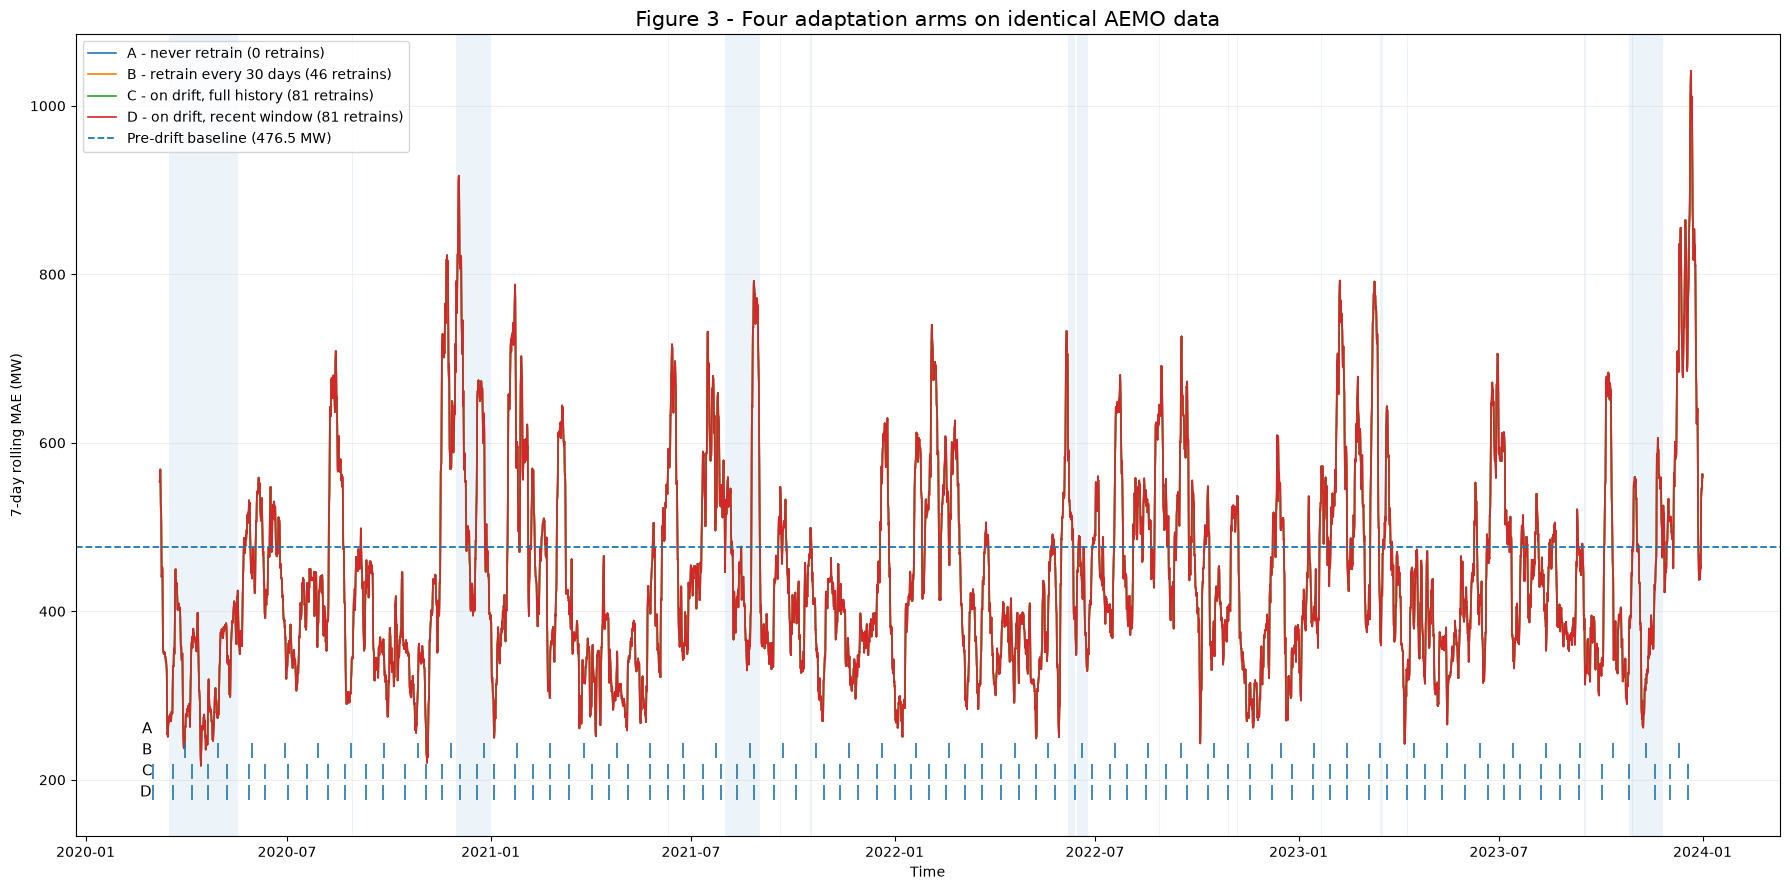

Saved to: figure3_four_adaptation_arms_final.png


In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 1. Ensure all four rolling-MAE series use datetime index
# --------------------------------------------------

arm_a_rolling_mae = pd.Series(
    arm_a_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d",
)

arm_b_rolling_mae = pd.Series(
    arm_b_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d",
)

arm_c_rolling_mae = pd.Series(
    arm_c_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d",
)

arm_d_rolling_mae = pd.Series(
    arm_d_rolling_mae.to_numpy(),
    index=test_y.index,
    name="rolling_mae_7d",
)


# --------------------------------------------------
# 2. Pre-drift baseline
#    Use the pre-drift MAE already calculated earlier
# --------------------------------------------------

pre_drift_baseline = regime_mae["pre_drift"]

print("Pre-drift baseline:", pre_drift_baseline)


# --------------------------------------------------
# 3. Create figure
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(18, 9))


# --------------------------------------------------
# 4. Plot the four adaptation arms
# --------------------------------------------------

ax.plot(
    arm_a_rolling_mae.index,
    arm_a_rolling_mae,
    linewidth=1.2,
    label="A - never retrain (0 retrains)",
)

ax.plot(
    arm_b_rolling_mae.index,
    arm_b_rolling_mae,
    linewidth=1.2,
    label="B - retrain every 30 days (46 retrains)",
)

ax.plot(
    arm_c_rolling_mae.index,
    arm_c_rolling_mae,
    linewidth=1.2,
    label=f"C - on drift, full history ({len(arm_c_retrains)} retrains)",
)

ax.plot(
    arm_d_rolling_mae.index,
    arm_d_rolling_mae,
    linewidth=1.2,
    label=f"D - on drift, recent window ({len(arm_d_retrains)} retrains)",
)


# --------------------------------------------------
# 5. Pre-drift baseline reference line
# --------------------------------------------------

ax.axhline(
    pre_drift_baseline,
    linestyle="--",
    linewidth=1.3,
    label=f"Pre-drift baseline ({pre_drift_baseline:.1f} MW)",
)


# --------------------------------------------------
# 6. Shade documented drift periods
# --------------------------------------------------

for _, event in event_windows.iterrows():
    drift_start = pd.to_datetime(event["drift_start"])
    drift_end = pd.to_datetime(event["drift_end"])

    # only shade events that overlap the test period
    if drift_end >= test_y.index.min() and drift_start <= test_y.index.max():
        ax.axvspan(
            max(drift_start, test_y.index.min()),
            min(drift_end, test_y.index.max()),
            alpha=0.08,
        )


# --------------------------------------------------
# 7. Retrain-event rows
# --------------------------------------------------

row_y = {
    "A": 260,
    "B": 235,
    "C": 210,
    "D": 185,
}

# A: never retrain — label only
ax.text(
    test_y.index.min(),
    row_y["A"],
    "A",
    va="center",
    ha="right",
    fontsize=11,
)

# B: actual scheduled retrain dates from Ishan's runner
for dt in pd.to_datetime(arm_b_retrains["retrain_date"]):
    ax.vlines(
        dt,
        row_y["B"] - 9,
        row_y["B"] + 9,
        linewidth=1.2,
    )

ax.text(
    test_y.index.min(),
    row_y["B"],
    "B",
    va="center",
    ha="right",
    fontsize=11,
)

# C: drift-triggered, full-history retrains
for dt in pd.to_datetime(arm_c_retrains["alarm_day"]):
    ax.vlines(
        dt,
        row_y["C"] - 9,
        row_y["C"] + 9,
        linewidth=1.2,
    )

ax.text(
    test_y.index.min(),
    row_y["C"],
    "C",
    va="center",
    ha="right",
    fontsize=11,
)

# D: drift-triggered, recent-window retrains
for dt in pd.to_datetime(arm_d_retrains["alarm_day"]):
    ax.vlines(
        dt,
        row_y["D"] - 9,
        row_y["D"] + 9,
        linewidth=1.2,
    )

ax.text(
    test_y.index.min(),
    row_y["D"],
    "D",
    va="center",
    ha="right",
    fontsize=11,
)


# --------------------------------------------------
# 8. Labels and formatting
# --------------------------------------------------

ax.set_title(
    "Figure 3 - Four adaptation arms on identical AEMO data",
    fontsize=15,
)

ax.set_xlabel("Time")
ax.set_ylabel("7-day rolling MAE (MW)")

ax.legend(
    loc="upper left",
)

ax.grid(
    axis="y",
    alpha=0.2,
)

plt.tight_layout()


# --------------------------------------------------
# 9. Save final F3
# --------------------------------------------------

output_path = "figure3_four_adaptation_arms_final.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved to:", output_path)

In [88]:
import pandas as pd

table3_final = pd.DataFrame([
    {
        "arm": "C - drift + full history",
        "region": REGION,
        "MAE pre-drift": round(regime_mae["pre_drift"], 2),
        "MAE drift": round(regime_mae["drift"], 2),
        "MAE post-drift": round(regime_mae["post_drift"], 2),
        "pinball loss": "Pending UQ",
        "seeds": "Pending",
    },
    {
        "arm": "D - drift + recent window",
        "region": REGION,
        "MAE pre-drift": round(regime_mae_d["pre_drift"], 2),
        "MAE drift": round(regime_mae_d["drift"], 2),
        "MAE post-drift": round(regime_mae_d["post_drift"], 2),
        "pinball loss": "Pending UQ",
        "seeds": "Pending",
    },
])

table3_final

,arm,region,MAE pre-drift,MAE drift,MAE post-drift,pinball loss,seeds
0,C - drift + full history,NSW1,476.52,415.94,443.12,Pending UQ,Pending
1,D - drift + recent window,NSW1,476.52,415.94,443.12,Pending UQ,Pending


In [93]:
# Calculate gains directly from the MAEs we already have
arm_c_gain_vs_a = arm_a_mae - arm_c_mae
arm_d_gain_vs_a = arm_a_mae - arm_d_mae

arm_c_gain_per_retrain = (
    arm_c_gain_vs_a / len(arm_c_retrains)
    if len(arm_c_retrains) > 0
    else 0
)

arm_d_gain_per_retrain = (
    arm_d_gain_vs_a / len(arm_d_retrains)
    if len(arm_d_retrains) > 0
    else 0
)

table4_final = pd.DataFrame([
    {
        "arm": "C - drift + full history",
        "retrains": len(arm_c_retrains),
        "cumulative train samples": cumulative_train_samples,
        "wall clock (s)": round(arm_c_wall_clock, 2),
        "MAE gain vs arm A": round(arm_c_gain_vs_a, 2),
        "gain per retrain": round(arm_c_gain_per_retrain, 2),
    },
    {
        "arm": "D - drift + recent window",
        "retrains": len(arm_d_retrains),
        "cumulative train samples": arm_d_cumulative_train_samples,
        "wall clock (s)": round(arm_d_wall_clock, 2),
        "MAE gain vs arm A": round(arm_d_gain_vs_a, 2),
        "gain per retrain": round(arm_d_gain_per_retrain, 2),
    },
])

table4_final

,arm,retrains,cumulative train samples,wall clock (s),MAE gain vs arm A,gain per retrain
0,C - drift + full history,81,5780846,1.43,0.0,0.0
1,D - drift + recent window,81,389855,24.89,0.0,0.0


In [94]:
table3_final.to_csv("table3_final.csv", index=False)
table4_final.to_csv("table4_final.csv", index=False)

print("Saved: table3_final.csv")
print("Saved: table4_final.csv")

Saved: table3_final.csv
Saved: table4_final.csv


In [99]:
import matplotlib.pyplot as plt

def save_table_image(
    df,
    title,
    badge,
    filename,
    figsize=(16, 3.5),
    col_widths=None,
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    # Badge
    ax.text(
        0.02,
        0.90,
        badge,
        fontsize=16,
        fontweight="bold",
        transform=ax.transAxes,
    )

    # Title
    ax.text(
        0.09,
        0.90,
        title,
        fontsize=18,
        fontweight="bold",
        transform=ax.transAxes,
    )

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        bbox=[0.02, 0.10, 0.96, 0.58],
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1, 1.8)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(
                weight="bold"
            )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved to:", filename)

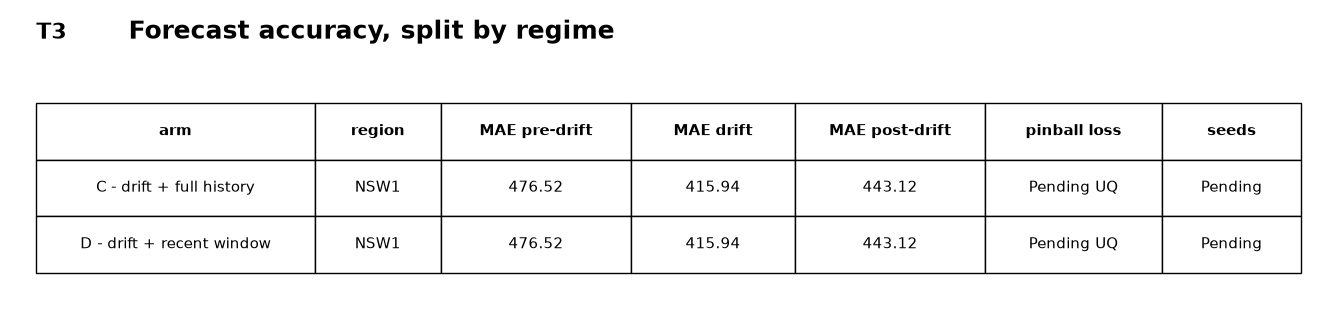

Saved to: table3_final.png


In [102]:
save_table_image(
    table3_final,
    title="Forecast accuracy, split by regime",
    badge="T3",
    filename="table3_final.png",
    figsize=(17, 3.8),
    col_widths=[
        0.22,  # arm
        0.10,  # region
        0.15,  # MAE pre-drift
        0.13,  # MAE drift
        0.15,  # MAE post-drift
        0.14,  # pinball loss
        0.11,  # seeds
    ],
)

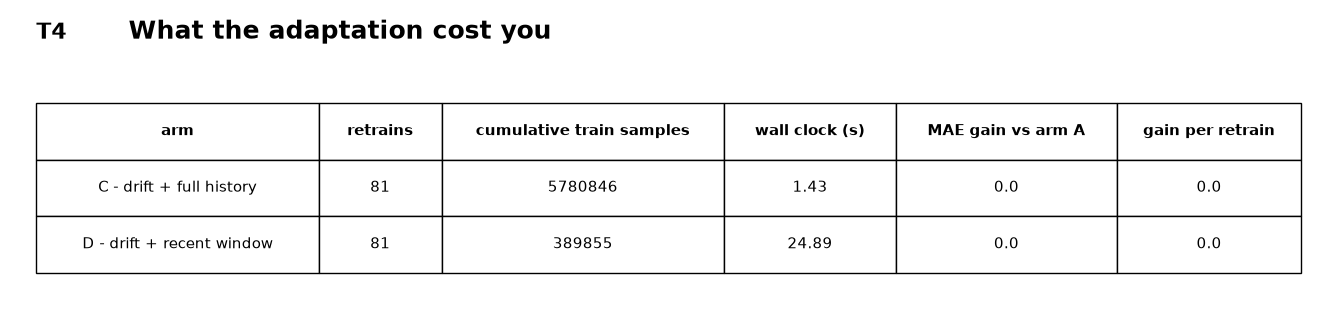

Saved to: table4_final.png


In [103]:
save_table_image(
    table4_final,
    title="What the adaptation cost you",
    badge="T4",
    filename="table4_final.png",
    figsize=(17, 3.8),
    col_widths=[
        0.23,  # arm
        0.10,  # retrains
        0.23,  # cumulative train samples
        0.14,  # wall clock
        0.18,  # MAE gain vs arm A
        0.15,  # gain per retrain
    ],
)

In [104]:
print("C overall MAE:", arm_c_mae)
print("D overall MAE:", arm_d_mae)

print(
    "Predictions identical:",
    np.allclose(
        arm_c_pred.to_numpy(),
        arm_d_pred.to_numpy(),
        equal_nan=True
    )
)

print("C retrains:", len(arm_c_retrains))
print("D retrains:", len(arm_d_retrains))

print(
    "C cumulative train samples:",
    cumulative_train_samples
)

print(
    "D cumulative train samples:",
    arm_d_cumulative_train_samples
)

C overall MAE: 442.2665021784711
D overall MAE: 442.2665021784711
Predictions identical: True
C retrains: 81
D retrains: 81
C cumulative train samples: 5780846
D cumulative train samples: 389855


In [105]:
print(
    "C rolling mean:",
    arm_c_rolling_mae.mean()
)

print(
    "C rolling max:",
    arm_c_rolling_mae.max()
)

print(
    "D rolling mean:",
    arm_d_rolling_mae.mean()
)

print(
    "D rolling max:",
    arm_d_rolling_mae.max()
)

C rolling mean: 441.4298226872944
C rolling max: 1041.5823908730158
D rolling mean: 441.4298226872944
D rolling max: 1041.5823908730158


In [106]:
print(inspect.getsource(assign_regime))

def assign_regime(detected_timestamps, event_windows):
    """
    Assign one regime and event ID to every detection timestamp.

    Priority:
        drift > pre_drift > event-linked post_drift
        > general post_drift > pre_drift fallback

    Attribution:
        - drift:
          Use the matching event ID.
        - pre_drift:
          Use the upcoming event ID.
        - event-linked post_drift:
          Use the event ID when the timestamp falls between that
          event's drift_end and post_drift_end.
        - general post_drift:
          If an earlier event exists but the timestamp falls outside
          every event window, use event_id="unassigned".
        - before all events:
          Use regime="pre_drift" and event_id="unassigned".

    When multiple windows overlap:
        - drift and pre_drift use the earliest event by drift_start;
        - post_drift uses the most recently started applicable event.
    """
    required_columns = {
        "event_id",
    

In [107]:
print(inspect.getsource(build_event_windows))

def build_event_windows(
    events,
    region,
    pre_drift_days=REGIME_PRE_DRIFT_DAYS,
    post_drift_days=REGIME_POST_DRIFT_DAYS,
):
    """
    Build pre-drift, drift, and post-drift windows for documented events.

    Parameters
    ----------
    events : pandas.DataFrame
        Must contain columns: event_id, start_date, end_date,
        date_precision, region.
    region : str
        Filter events to this region before building windows.
    pre_drift_days : int
        Days before event start to begin pre-drift window.
    post_drift_days : int
        Days after event end to extend post-drift window.

    Returns
    -------
    pandas.DataFrame
        One row per event with columns: event_id, start_date, end_date,
        drift_start, drift_end, pre_drift_start, post_drift_end,
        date_precision.
    """
    df = events[events["region"].isin(["NEM", region])].copy()
    df["start_date"] = pd.to_datetime(df["start_date"])
    df["end_date"] = pd.to_datetime(df["end_

In [108]:
print("event_windows shape:", event_windows.shape)

display(
    event_windows[
        [
            "event_id",
            "start_date",
            "end_date",
            "pre_drift_start",
            "drift_start",
            "drift_end",
            "post_drift_end",
        ]
    ]
)

event_windows shape: (20, 8)


,event_id,start_date,end_date,pre_drift_start,drift_start,drift_end,post_drift_end
0,EVT-2020-01,2020-01-04,2020-01-04,2019-12-28,2020-01-04,2020-01-05,2020-01-12
1,EVT-2020-02,2020-03-16,2020-05-17,2020-03-09,2020-03-16,2020-05-18,2020-05-25
2,EVT-2020-04,2020-08-29,2020-08-29,2020-08-22,2020-08-29,2020-08-30,2020-09-06
3,EVT-2020-07,2020-12-01,2020-12-31,2020-11-24,2020-12-01,2021-01-01,2021-01-08
4,EVT-2021-08,2021-06-10,2021-06-10,2021-06-03,2021-06-10,2021-06-11,2021-06-18
5,EVT-2021-02,2021-08-01,2021-08-31,2021-07-25,2021-08-01,2021-09-01,2021-09-08
6,EVT-2021-03,2021-09-19,2021-09-19,2021-09-12,2021-09-19,2021-09-20,2021-09-27
7,EVT-2021-05,2021-10-17,2021-10-17,2021-10-10,2021-10-17,2021-10-18,2021-10-25
8,EVT-2022-02,2022-06-07,2022-06-12,2022-05-31,2022-06-07,2022-06-13,2022-06-20
9,EVT-2022-03,2022-06-15,2022-06-24,2022-06-08,2022-06-15,2022-06-25,2022-07-02


In [110]:
import drift_lab.evaluation.evaluation as eval_mod

print("REGIME_PRE_DRIFT_DAYS =", eval_mod.REGIME_PRE_DRIFT_DAYS)
print("REGIME_POST_DRIFT_DAYS =", eval_mod.REGIME_POST_DRIFT_DAYS)

REGIME_PRE_DRIFT_DAYS = 7
REGIME_POST_DRIFT_DAYS = 7


In [111]:
import numpy as np

check_df = pd.DataFrame({
    "actual": test_y.to_numpy(),
    "pred_c": arm_c_pred.to_numpy(),
    "pred_d": arm_d_pred.to_numpy(),
    "regime": regime_df["regime"].to_numpy(),
})

for regime in ["pre_drift", "drift", "post_drift"]:
    part = check_df[check_df["regime"] == regime]

    mae_c = np.mean(np.abs(part["actual"] - part["pred_c"]))
    mae_d = np.mean(np.abs(part["actual"] - part["pred_d"]))

    print(
        regime,
        "rows =", len(part),
        "C MAE =", mae_c,
        "D MAE =", mae_d,
    )

pre_drift rows = 5472 C MAE = 476.52421631335284 D MAE = 476.52421631335284
drift rows = 8832 C MAE = 415.93996263586956 D MAE = 415.93996263586956
post_drift rows = 52945 C MAE = 443.11753221896936 D MAE = 443.11753221896936


In [112]:
print("C retrains:", len(arm_c_retrains))
print("D retrains:", len(arm_d_retrains))

print("C cumulative train samples:", cumulative_train_samples)
print("D cumulative train samples:", arm_d_cumulative_train_samples)

C retrains: 81
D retrains: 81
C cumulative train samples: 5780846
D cumulative train samples: 389855


In [113]:
print("C wall clock:", arm_c_wall_clock)
print("D wall clock:", arm_d_wall_clock)

C wall clock: 1.4341175000008661
D wall clock: 24.894947499997215


In [114]:
print("Arm A overall MAE:", arm_a_mae)
print("Arm C overall MAE:", arm_c_mae)
print("Arm D overall MAE:", arm_d_mae)

print("C gain vs A:", arm_c_gain_vs_a)
print("D gain vs A:", arm_d_gain_vs_a)

print("C gain per retrain:", arm_c_gain_per_retrain)
print("D gain per retrain:", arm_d_gain_per_retrain)

Arm A overall MAE: 442.2665021784711
Arm C overall MAE: 442.2665021784711
Arm D overall MAE: 442.2665021784711
C gain vs A: 0.0
D gain vs A: 0.0
C gain per retrain: 0.0
D gain per retrain: 0.0
